# Notebook 07 — Xây dựng và Đánh giá Mô hình

**Mục tiêu**: Train, evaluate và chọn mô hình dự báo doanh thu tốt nhất
- Baseline model
- XGBoost / LightGBM/ Catboost
- So sánh models theo MAE, RMSE, R², Adjusted R-Square

**Tương ứng báo cáo**: Phần 2 — Chương 6 (Xây dựng và đánh giá mô hình dự báo)

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats
from prophet import Prophet

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.tsa.stattools import adfuller
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
sys.path.append("..")

from src.data_loader import load_processed
from src.preprocessing import prepare_stl_dataframe
from src.evaluation import evaluate
from src.feature_engineering import build_aux_features, engineer_features

# Config
FIG_DIR = Path("../outputs/figures/model")
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

%matplotlib inline

c:\Users\lenovo\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
sales      = load_processed('sales_clean.csv')
orders     = load_processed('orders_clean.csv')
order_items = load_processed('order_items_clean.csv')
products   = load_processed('products_clean.csv')
returns    = load_processed('returns_clean.csv')
web_traffic = load_processed('web_traffic_clean.csv')
payments   = load_processed('payments_clean.csv')
promotions = load_processed('promotions_clean.csv')
inventory   = load_processed('inventory_clean.csv')
shipping    = load_processed('shipments_clean.csv')

d:\KienTap_RevenueEcommerce\revenue_forecast_ecommerce\notebooks\..\src\data_loader.py:40: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(PROCESSED / subfolder / filename)


### 1. Hàm chia tách dữ liệu train test theo expanding window

In [14]:
def create_expanding_window_splits(data):

    # =====================================================
    # PREP DATA
    # =====================================================

    dataset = (
    data[['LogRevenue']]
    .reset_index()
)

    dataset.columns = ['ds', 'y']

    dataset['ds'] = pd.to_datetime(dataset['ds'])

    # =====================================================
    # SPLITS (EXPANDING WINDOW - 4 FOLDS)
    # =====================================================

    splits = [
    {'fold': 1, 'test_start': '2021-01-01', 'test_end': '2021-06-30'},
    {'fold': 2, 'test_start': '2021-07-01', 'test_end': '2021-12-31'},
    {'fold': 3, 'test_start': '2022-01-01', 'test_end': '2022-06-30'},  # FIX HERE
    {'fold': 4, 'test_start': '2022-07-01', 'test_end': '2022-12-31'}
]

    fold_data = []

    # =====================================================
    # BUILD FOLDS
    # =====================================================

    for split in splits:

        test_start = pd.to_datetime(split['test_start'])
        test_end = pd.to_datetime(split['test_end'])

        # train_end = day before test_start
        train_end = test_start - pd.Timedelta(days=1)

        # expanding train
        train = dataset[
            dataset['ds'] <= train_end
        ].reset_index(drop=True)

        test = dataset[
            (dataset['ds'] >= test_start) &
            (dataset['ds'] <= test_end)
        ].reset_index(drop=True)

        fold_data.append({
            'fold': split['fold'],
            'train_end': train_end,
            'train': train,
            'test': test
        })

        # =================================================
        # PRINT INFO
        # =================================================

        print(f"\n{'='*60}")
        print(f"FOLD {split['fold']}")
        print(f"{'='*60}")

        print(
            f"Train : {train['ds'].min().date()} -> {train['ds'].max().date()} "
            f"| Size = {len(train)}"
        )

        print(
            f"Test  : {test['ds'].min().date()} -> {test['ds'].max().date()} "
            f"| Size = {len(test)}"
        )

    return fold_data

### 2. Xây dựng mô hình Baseline

#### 2.1. Kết quả thực nghiệm


FOLD 1
Train : 2012-07-04 -> 2020-12-31 | Size = 3103
Test  : 2021-01-01 -> 2021-06-30 | Size = 181

FOLD 2
Train : 2012-07-04 -> 2021-06-30 | Size = 3284
Test  : 2021-07-01 -> 2021-12-31 | Size = 184

FOLD 3
Train : 2012-07-04 -> 2021-12-31 | Size = 3468
Test  : 2022-01-01 -> 2022-06-30 | Size = 181

FOLD 4
Train : 2012-07-04 -> 2022-06-30 | Size = 3649
Test  : 2022-07-01 -> 2022-12-31 | Size = 184

FOLD 1

 Fold 1 - SEASONAL NAIVE
  MAE            : 703646.8905
  RMSE           : 946159.8421
  R²             : 0.7511
  Adjusted R²    : 0.7511



17:24:57 - cmdstanpy - INFO - Chain [1] start processing
17:24:58 - cmdstanpy - INFO - Chain [1] done processing



 Fold 1 - PROPHET RAW
  MAE            : 1040496.5588
  RMSE           : 1576166.8437
  R²             : 0.3094
  Adjusted R²    : 0.3056


 Fold 1 - PROPHET DUAN
  MAE            : 1002211.9853
  RMSE           : 1498425.7949
  R²             : 0.3759
  Adjusted R²    : 0.3724



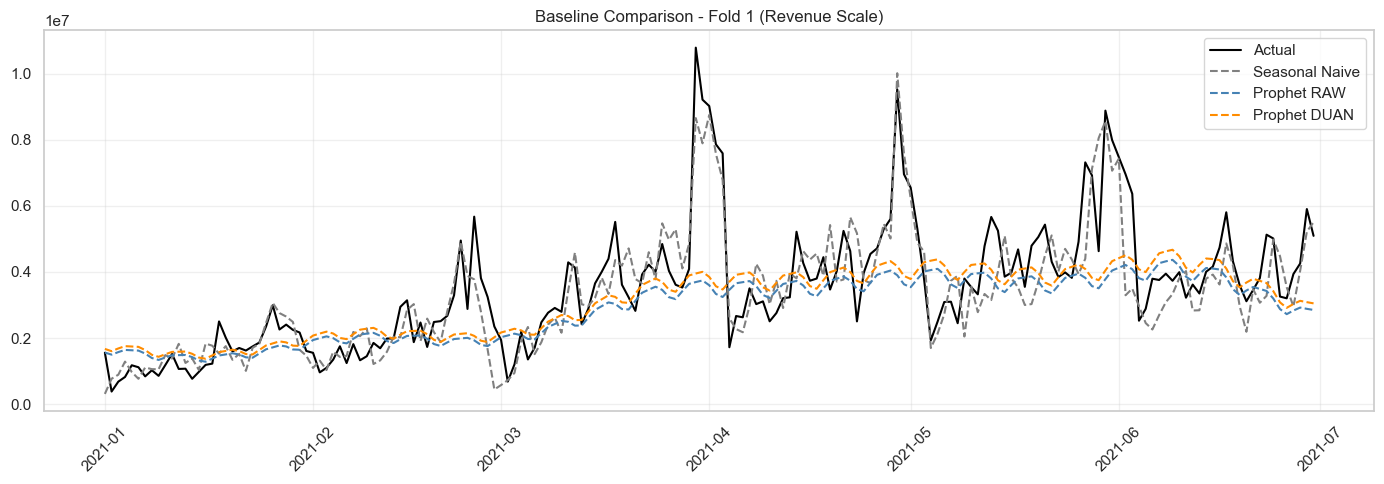


FOLD 2

 Fold 2 - SEASONAL NAIVE
  MAE            : 716404.5241
  RMSE           : 1082243.9903
  R²             : -0.1466
  Adjusted R²    : -0.1466



17:24:59 - cmdstanpy - INFO - Chain [1] start processing
17:25:00 - cmdstanpy - INFO - Chain [1] done processing



 Fold 2 - PROPHET RAW
  MAE            : 629149.9804
  RMSE           : 847029.8577
  R²             : 0.2977
  Adjusted R²    : 0.2938


 Fold 2 - PROPHET DUAN
  MAE            : 679510.1647
  RMSE           : 869109.3697
  R²             : 0.2606
  Adjusted R²    : 0.2565



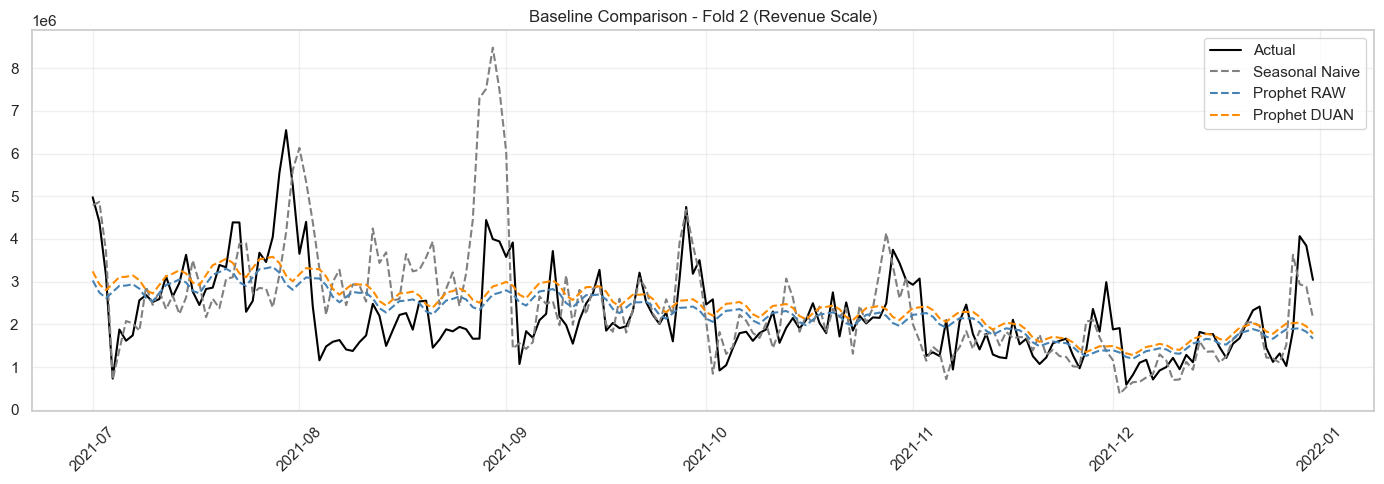


FOLD 3

 Fold 3 - SEASONAL NAIVE
  MAE            : 884456.2643
  RMSE           : 1181931.6616
  R²             : 0.5794
  Adjusted R²    : 0.5794



17:25:01 - cmdstanpy - INFO - Chain [1] start processing
17:25:02 - cmdstanpy - INFO - Chain [1] done processing



 Fold 3 - PROPHET RAW
  MAE            : 1195806.6499
  RMSE           : 1666406.7282
  R²             : 0.1640
  Adjusted R²    : 0.1593


 Fold 3 - PROPHET DUAN
  MAE            : 1114523.4798
  RMSE           : 1576335.1062
  R²             : 0.2519
  Adjusted R²    : 0.2478



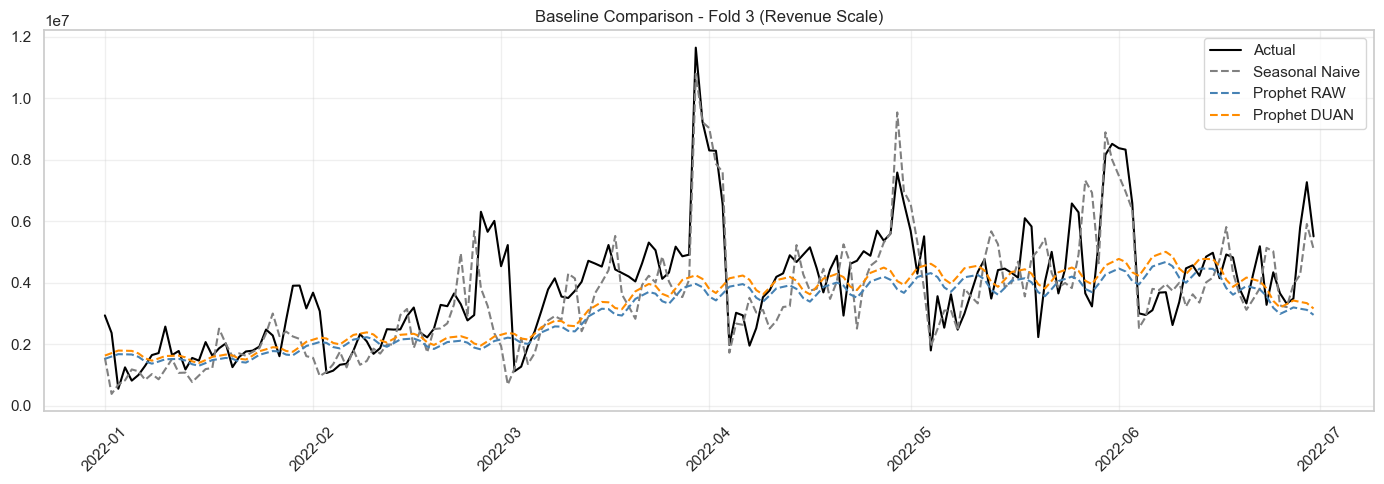


FOLD 4

 Fold 4 - SEASONAL NAIVE
  MAE            : 791714.1829
  RMSE           : 1141688.6193
  R²             : 0.1524
  Adjusted R²    : 0.1524



17:25:03 - cmdstanpy - INFO - Chain [1] start processing
17:25:04 - cmdstanpy - INFO - Chain [1] done processing



 Fold 4 - PROPHET RAW
  MAE            : 708823.4240
  RMSE           : 1066711.5353
  R²             : 0.2600
  Adjusted R²    : 0.2560


 Fold 4 - PROPHET DUAN
  MAE            : 722300.8444
  RMSE           : 1048843.3895
  R²             : 0.2846
  Adjusted R²    : 0.2807



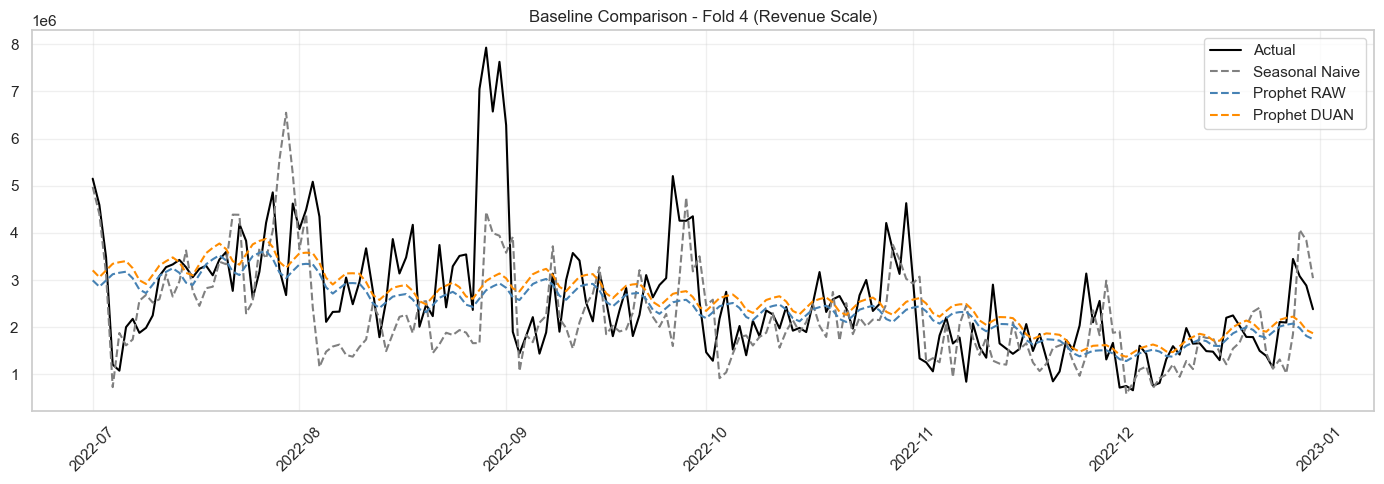


FINAL RESULTS - REVENUE SCALE


,Fold,Model,MAE,RMSE,R2,Adj_R2
0,1,Seasonal Naive,7.036469e+05,9.461598e+05,0.7511,0.7511
1,1,Prophet RAW,1.040497e+06,1.576167e+06,0.3094,0.3056
2,1,Prophet DUAN,1.002212e+06,1.498426e+06,0.3759,0.3724
3,2,Seasonal Naive,7.164045e+05,1.082244e+06,-0.1466,-0.1466
4,2,Prophet RAW,6.291500e+05,8.470299e+05,0.2977,0.2938
5,2,Prophet DUAN,6.795102e+05,8.691094e+05,0.2606,0.2565
6,3,Seasonal Naive,8.844563e+05,1.181932e+06,0.5794,0.5794
7,3,Prophet RAW,1.195807e+06,1.666407e+06,0.1640,0.1593
8,3,Prophet DUAN,1.114523e+06,1.576335e+06,0.2519,0.2478
9,4,Seasonal Naive,7.917142e+05,1.141689e+06,0.1524,0.1524



AVERAGE PERFORMANCE COMPARISON


,MAE,RMSE,R2,Adj_R2
Model,,,,
Seasonal Naive,"774,055.47","1,088,006.03",0.3341,0.3341
Prophet DUAN,"879,636.62","1,248,178.42",0.2933,0.2893
Prophet RAW,"893,569.15","1,289,078.74",0.2578,0.2537


In [15]:
stl_df = prepare_stl_dataframe(sales)

fold_splits = create_expanding_window_splits(stl_df)

fold_rows = []
all_y_true_log = []
all_y_pred_log = []

for split in fold_splits:

    fold  = split['fold']
    train = split['train'].copy()
    test  = split['test'].copy()

    print(f"\n{'='*70}")
    print(f'FOLD {fold}')
    print(f"{'='*70}")

    train['ds'] = pd.to_datetime(train['ds'])
    test['ds']  = pd.to_datetime(test['ds'])

    train = train[['ds', 'y']]
    test  = test[['ds', 'y']]

    # y ở đây là LogRevenue → back-transform để evaluate trên revenue thật
    y_true_log = test['y'].values
    y_true_rev = np.expm1(y_true_log)

    # =====================================================
    # SEASONAL NAIVE BASELINE
    # =====================================================
    naive_preds_rev = []

    for ds in test['ds']:
        target_date = ds - pd.Timedelta(days=365)

        match = train[train['ds'] == target_date]['y']

        if len(match) > 0:
            naive_log = match.values[0]
        else:
            diff = (train['ds'] - target_date).abs()
            naive_log = train.loc[diff.idxmin(), 'y']

        naive_preds_rev.append(np.expm1(naive_log))

    y_pred_naive_rev = np.array(naive_preds_rev)

    metrics_naive = evaluate(
        y_true=y_true_rev,
        y_pred=y_pred_naive_rev,
        n_features=0,
        label=f'Fold {fold} - SEASONAL NAIVE'
    )

    # =====================================================
    # PROPHET
    # =====================================================
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.1,
        seasonality_mode='multiplicative'
    )

    model.fit(train)

    future = model.make_future_dataframe(
        periods=len(test),
        freq='D'
    )

    forecast = model.predict(future)

    forecast_test = (
        forecast[['ds', 'yhat']]
        .merge(test, on='ds', how='inner')
    )

    forecast_train = (
        forecast[['ds', 'yhat']]
        .merge(train, on='ds', how='inner')
    )

    y_pred_log = forecast_test['yhat'].values
    y_pred_log = forecast_test['yhat'].values

    all_y_true_log.append(y_true_log)
    all_y_pred_log.append(y_pred_log)

    y_pred_raw_rev = np.expm1(y_pred_log)

    train_residuals = (
        forecast_train['y'].values
        - forecast_train['yhat'].values
    )

    smearing_factor = np.mean(
        np.exp(train_residuals)
    )

    y_pred_duan_rev = (
        np.expm1(y_pred_log)
        * smearing_factor
    )

    metrics_raw = evaluate(
        y_true=y_true_rev,
        y_pred=y_pred_raw_rev,
        n_features=1,
        label=f'Fold {fold} - PROPHET RAW'
    )

    metrics_duan = evaluate(
        y_true=y_true_rev,
        y_pred=y_pred_duan_rev,
        n_features=1,
        label=f'Fold {fold} - PROPHET DUAN'
    )

    for model_name, metrics in [
        ('Seasonal Naive', metrics_naive),
        ('Prophet RAW', metrics_raw),
        ('Prophet DUAN', metrics_duan)
    ]:

        fold_rows.append({
            'Fold': fold,
            'Model': model_name,
            'MAE': metrics['MAE'],
            'RMSE': metrics['RMSE'],
            'R2': metrics['R2'],
            'Adj_R2': metrics['Adjusted_R2']
        })


    # =====================================================
    # PLOT
    # =====================================================
    plt.figure(figsize=(14, 5))
    plt.plot(test['ds'], y_true_rev,       label='Actual',          color='black')
    plt.plot(test['ds'], y_pred_naive_rev, label='Seasonal Naive',  color='gray',      linestyle='--')
    plt.plot(test['ds'], y_pred_raw_rev,   label='Prophet RAW',     color='steelblue', linestyle='--')
    plt.plot(test['ds'], y_pred_duan_rev,  label='Prophet DUAN',    color='darkorange',linestyle='--')
    plt.title(f'Baseline Comparison - Fold {fold} (Revenue Scale)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# =========================================================
# RESULT TABLE
# =========================================================
results = pd.DataFrame(fold_rows)

print("\n" + "="*70)
print("FINAL RESULTS - REVENUE SCALE")
print("="*70)
display(results)

print("\n" + "="*70)
print("AVERAGE PERFORMANCE COMPARISON")
print("="*70)
avg = (
    results
    .groupby('Model')[['MAE', 'RMSE', 'R2', 'Adj_R2']]
    .mean()
    .sort_values('RMSE')
)

# format cho dễ đọc (không scientific notation)
avg_display = avg.copy()
avg_display['MAE'] = avg_display['MAE'].apply(lambda x: f"{x:,.2f}")
avg_display['RMSE'] = avg_display['RMSE'].apply(lambda x: f"{x:,.2f}")
avg_display['R2'] = avg_display['R2'].apply(lambda x: f"{x:.4f}")
avg_display['Adj_R2'] = avg_display['Adj_R2'].apply(lambda x: f"{x:.4f}")

display(avg_display)


- Seasonal Naive là mô hình baseline tốt nhất với RMSE ≈ 1,09 triệu đồng và R² = 0,3341, cho thấy doanh thu có tính mùa vụ năm rõ rệt và thông tin cùng kỳ năm trước mang giá trị dự báo cao.

- Prophet DUAN cải thiện so với Prophet RAW (RMSE giảm từ 1,29 triệu xuống 1,25 triệu đồng; R² tăng từ 0,2565 lên 0,2922), cho thấy hiệu chỉnh Duan giúp giảm sai lệch khi chuyển đổi từ log doanh thu về doanh thu thực tế.

- Tuy nhiên, cả hai phiên bản Prophet vẫn kém Seasonal Naive, phản ánh rằng đặc tính mùa vụ ổn định của chuỗi doanh thu được khai thác hiệu quả hơn bằng phương pháp dự báo cùng kỳ năm trước.

- Prophet DUAN được chọn làm baseline cho các mô hình hybrid ở các phần tiếp theo nhờ hiệu suất tốt hơn Prophet RAW và khả năng hỗ trợ học phần sai số còn lại.

#### 2.2 Phân tích phần dư của mô hình Prophet DUAN


In [5]:
# =========================================================
# WHITE NOISE DIAGNOSTIC
# =========================================================
def check_white_noise(y_true_log, y_pred_log, fold=None):

    residuals = np.asarray(y_true_log) - np.asarray(y_pred_log)

    print("\n" + "=" * 70)
    print(f"FOLD {fold} - WHITE NOISE DIAGNOSTIC (LOG SPACE)")
    print("=" * 70)

    # =====================================================
    # 1. SUMMARY STATISTICS
    # =====================================================
    mean_val = residuals.mean()
    std_val = residuals.std()
    skew_val = stats.skew(residuals)
    kurt_val = stats.kurtosis(residuals)

    print("\n[1] SUMMARY")
    print(f"Mean     : {mean_val:.6f}")
    print(f"Std      : {std_val:.6f}")
    print(f"Skew     : {skew_val:.6f}")
    print(f"Kurtosis : {kurt_val:.6f}")

    # =====================================================
    # 2. ACF / PACF
    # =====================================================
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    plot_acf(residuals, lags=30, ax=axes[0])
    axes[0].set_title(f"ACF Residuals - Fold {fold}")

    plot_pacf(residuals, lags=20, method="ywm", ax=axes[1])
    axes[1].set_title(f"PACF Residuals - Fold {fold}")

    plt.tight_layout()
    plt.show()

    # =====================================================
    # 3. LJUNG-BOX TEST
    # =====================================================
    ljung_lags = [5, 10, 15, 20, 30]

    lb = acorr_ljungbox(
        residuals,
        lags=ljung_lags,
        return_df=True
    )

    print("\n[2] LJUNG-BOX TEST")
    print(lb)

    lb_pass_all = (lb["lb_pvalue"] > 0.05).all()

    print(
        "\nAutocorrelation:",
        "PASS (White Noise)"
        if lb_pass_all
        else "FAIL (Residual still contains autocorrelation)"
    )

    # =====================================================
    # 4. DURBIN-WATSON
    # =====================================================
    dw = durbin_watson(residuals)

    print("\n[3] DURBIN-WATSON")
    print(f"DW Statistic: {dw:.6f}")

    # =====================================================
    # 5. JARQUE-BERA
    # =====================================================
    jb_stat, jb_pval, _, _ = jarque_bera(residuals)

    print("\n[4] JARQUE-BERA (REFERENCE ONLY)")
    print(f"JB Statistic : {jb_stat:.6f}")
    print(f"JB p-value   : {jb_pval:.6f}")

    # =====================================================
    # 6. ADF
    # =====================================================
    adf_stat, adf_pval, *_ = adfuller(residuals)

    print("\n[5] ADF TEST (REFERENCE ONLY)")
    print(f"ADF Statistic : {adf_stat:.6f}")
    print(f"ADF p-value   : {adf_pval:.6f}")

    # =====================================================
    # RETURN
    # =====================================================
    return {
        "fold": fold,

        # summary
        "mean": mean_val,
        "std": std_val,
        "skew": skew_val,
        "kurtosis": kurt_val,

        # Ljung-Box
        "lb_pass": lb_pass_all,
        "lb_p_lag5": lb.loc[5, "lb_pvalue"],
        "lb_p_lag10": lb.loc[10, "lb_pvalue"],
        "lb_p_lag15": lb.loc[15, "lb_pvalue"],
        "lb_p_lag20": lb.loc[20, "lb_pvalue"],
        "lb_p_lag30": lb.loc[30, "lb_pvalue"],

        # DW
        "durbin_watson": dw,

        # reference
        "jb_pvalue": jb_pval,
        "adf_pvalue": adf_pval
    }


FOLD 1 - WHITE NOISE DIAGNOSTIC (LOG SPACE)

[1] SUMMARY
Mean     : 0.091945
Std      : 0.396415
Skew     : -0.273284
Kurtosis : 0.893258


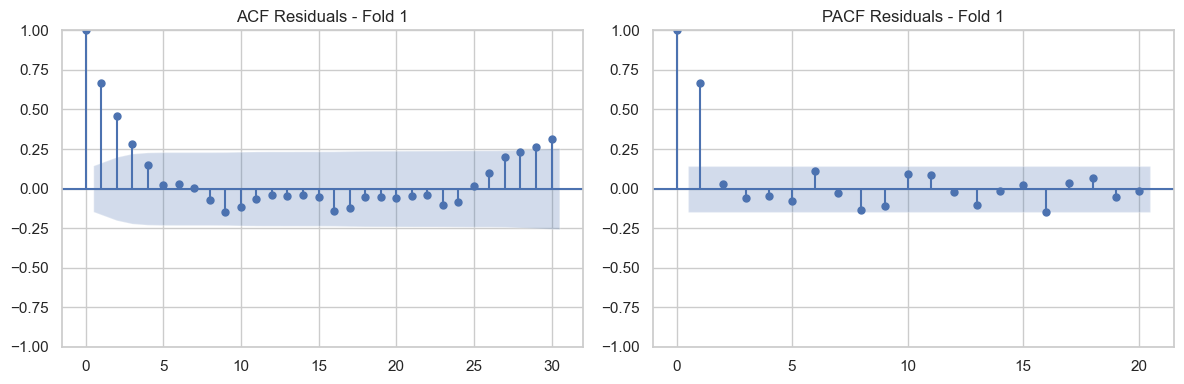


[2] LJUNG-BOX TEST
       lb_stat     lb_pvalue
5   139.149218  2.713315e-28
10  147.198897  1.404020e-26
15  149.932469  2.488159e-24
20  159.005805  1.167956e-23
30  221.890481  3.682628e-31

Autocorrelation: FAIL (Residual still contains autocorrelation)

[3] DURBIN-WATSON
DW Statistic: 0.626731

[4] JARQUE-BERA (REFERENCE ONLY)
JB Statistic : 8.270540
JB p-value   : 0.015998

[5] ADF TEST (REFERENCE ONLY)
ADF Statistic : -5.122329
ADF p-value   : 0.000013

FOLD 2 - WHITE NOISE DIAGNOSTIC (LOG SPACE)

[1] SUMMARY
Mean     : -0.082676
Std      : 0.355181
Skew     : -0.016623
Kurtosis : 0.512898


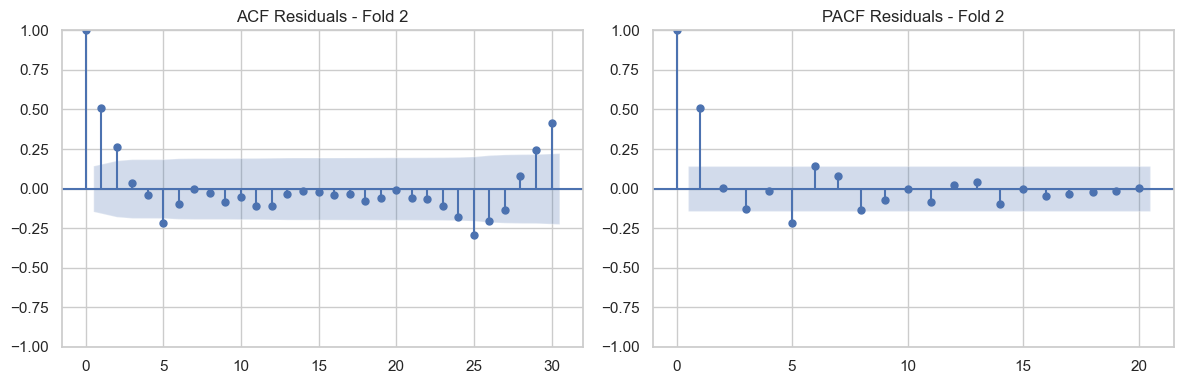


[2] LJUNG-BOX TEST
       lb_stat     lb_pvalue
5    70.703134  7.316108e-14
10   74.759458  5.299255e-12
15   79.727899  7.832175e-11
20   82.223642  1.640942e-09
30  177.832313  6.351566e-23

Autocorrelation: FAIL (Residual still contains autocorrelation)

[3] DURBIN-WATSON
DW Statistic: 0.899725

[4] JARQUE-BERA (REFERENCE ONLY)
JB Statistic : 2.025302
JB p-value   : 0.363255

[5] ADF TEST (REFERENCE ONLY)
ADF Statistic : -4.566447
ADF p-value   : 0.000149

FOLD 3 - WHITE NOISE DIAGNOSTIC (LOG SPACE)

[1] SUMMARY
Mean     : 0.171748
Std      : 0.384390
Skew     : -0.282648
Kurtosis : 0.649631


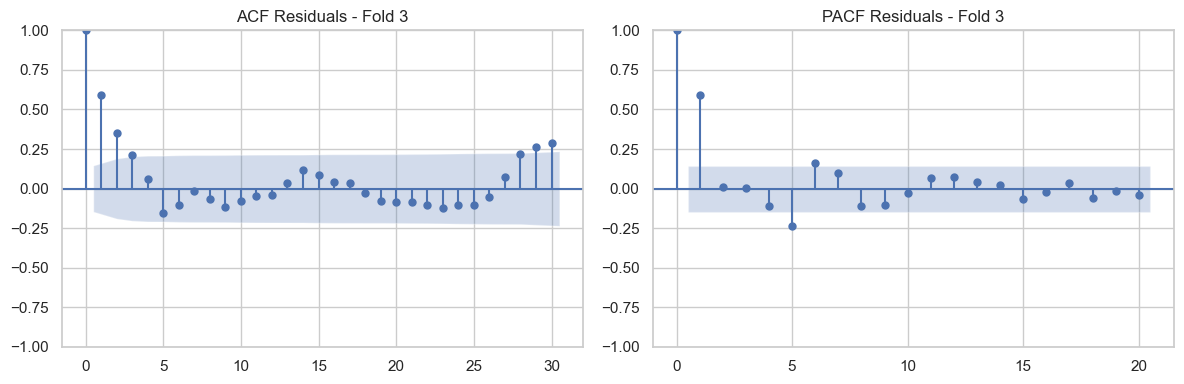


[2] LJUNG-BOX TEST
       lb_stat     lb_pvalue
5   100.680675  3.798241e-20
10  107.220317  1.937229e-18
15  112.484340  5.368498e-17
20  116.150241  1.465632e-15
30  172.534550  5.913075e-22

Autocorrelation: FAIL (Residual still contains autocorrelation)

[3] DURBIN-WATSON
DW Statistic: 0.671671

[4] JARQUE-BERA (REFERENCE ONLY)
JB Statistic : 5.592756
JB p-value   : 0.061031

[5] ADF TEST (REFERENCE ONLY)
ADF Statistic : -4.410806
ADF p-value   : 0.000284

FOLD 4 - WHITE NOISE DIAGNOSTIC (LOG SPACE)

[1] SUMMARY
Mean     : -0.005004
Std      : 0.366305
Skew     : 0.025884
Kurtosis : 0.584538


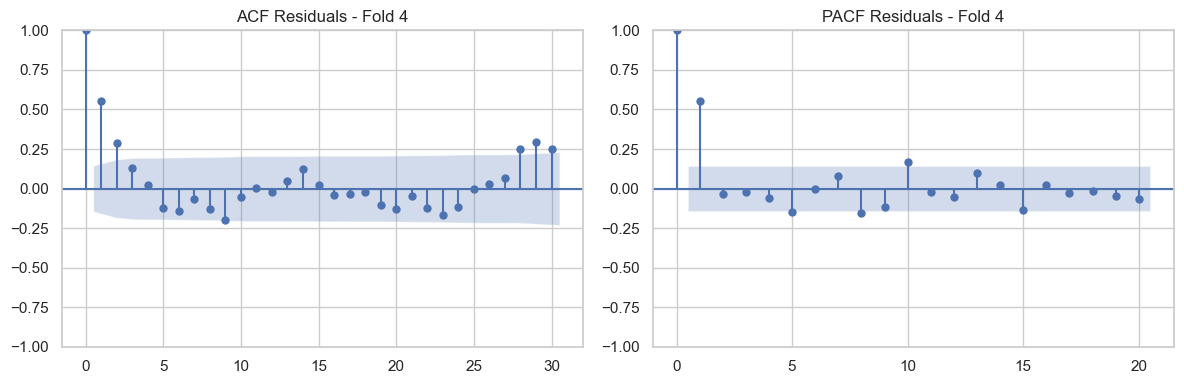


[2] LJUNG-BOX TEST
       lb_stat     lb_pvalue
5    79.453111  1.092078e-15
10   95.539273  4.240549e-16
15   99.123221  1.912443e-14
20  105.791337  1.142346e-13
30  166.084271  8.789864e-21

Autocorrelation: FAIL (Residual still contains autocorrelation)

[3] DURBIN-WATSON
DW Statistic: 0.872251

[4] JARQUE-BERA (REFERENCE ONLY)
JB Statistic : 2.640133
JB p-value   : 0.267118

[5] ADF TEST (REFERENCE ONLY)
ADF Statistic : -4.280023
ADF p-value   : 0.000481

WHITE NOISE DIAGNOSTIC SUMMARY


,fold,mean,std,skew,kurtosis,durbin_watson,lb_p_lag5,lb_p_lag10,lb_p_lag15,lb_p_lag20,lb_p_lag30,adf_pvalue,lb_pass
0,1,0.091945,0.396415,-0.273284,0.893258,0.626731,2.713315e-28,1.404020e-26,2.488159e-24,1.167956e-23,3.682628e-31,0.000013,False
1,2,-0.082676,0.355181,-0.016623,0.512898,0.899725,7.316108e-14,5.299255e-12,7.832175e-11,1.640942e-09,6.351566e-23,0.000149,False
2,3,0.171748,0.384390,-0.282648,0.649631,0.671671,3.798241e-20,1.937229e-18,5.368498e-17,1.465632e-15,5.913075e-22,0.000284,False
3,4,-0.005004,0.366305,0.025884,0.584538,0.872251,1.092078e-15,4.240549e-16,1.912443e-14,1.142346e-13,8.789864e-21,0.000481,False



FINAL WHITE NOISE CONCLUSION (ACROSS FOLDS)
Fail folds: 4/4
→ Residuals still contain significant autocorrelation.
→ Prophet has not fully captured all temporal patterns.
→ Hybrid Prophet + Machine Learning is justified.

AVERAGE RESIDUAL STATISTICS


,Metric,Average
0,Mean,0.0440
1,Std,0.3756
2,Skew,-0.1367
3,Kurtosis,0.6601
4,Durbin-Watson,0.7676


In [6]:
# =========================================================
# RUN DIAGNOSTICS FOR ALL FOLDS
# =========================================================
results = []
for i, split_info in enumerate(fold_splits):

    fold_num = split_info["fold"]

    y_true_log = all_y_true_log[i]
    y_pred_log = all_y_pred_log[i]

    res = check_white_noise(
        y_true_log,
        y_pred_log,
        fold=fold_num
    )

    results.append(res)

# =========================================================
# SUMMARY TABLE
# =========================================================
df_res = pd.DataFrame(results)

print("\n" + "=" * 70)
print("WHITE NOISE DIAGNOSTIC SUMMARY")
print("=" * 70)

display(
    df_res[
        [
            "fold",
            "mean",
            "std",
            "skew",
            "kurtosis",
            "durbin_watson",
            "lb_p_lag5",
            "lb_p_lag10",
            "lb_p_lag15",
            "lb_p_lag20",
            "lb_p_lag30",
            "adf_pvalue",
            "lb_pass"
        ]
    ]
)

# =========================================================
# FINAL CONCLUSION
# =========================================================
total_folds = len(df_res)

fail_folds = (~df_res["lb_pass"]).sum()

print("\n" + "=" * 70)
print("FINAL WHITE NOISE CONCLUSION (ACROSS FOLDS)")
print("=" * 70)

print(f"Fail folds: {fail_folds}/{total_folds}")

ratio = fail_folds / total_folds

if ratio >= 0.7:
    print(
        "→ Residuals still contain significant autocorrelation.\n"
        "→ Prophet has not fully captured all temporal patterns.\n"
        "→ Hybrid Prophet + Machine Learning is justified."
    )

elif ratio >= 0.3:
    print(
        "→ Residuals show partial autocorrelation.\n"
        "→ Further tuning or feature engineering may be beneficial."
    )

else:
    print(
        "→ Residuals are close to white noise.\n"
        "→ Limited opportunity for additional improvement."
    )

# =========================================================
# OPTIONAL: AVERAGE STATISTICS
# =========================================================
print("\n" + "=" * 70)
print("AVERAGE RESIDUAL STATISTICS")
print("=" * 70)

summary = pd.DataFrame({
    "Metric": [
        "Mean",
        "Std",
        "Skew",
        "Kurtosis",
        "Durbin-Watson"
    ],
    "Average": [
        df_res["mean"].mean(),
        df_res["std"].mean(),
        df_res["skew"].mean(),
        df_res["kurtosis"].mean(),
        df_res["durbin_watson"].mean()
    ]
})

display(summary.round(4))

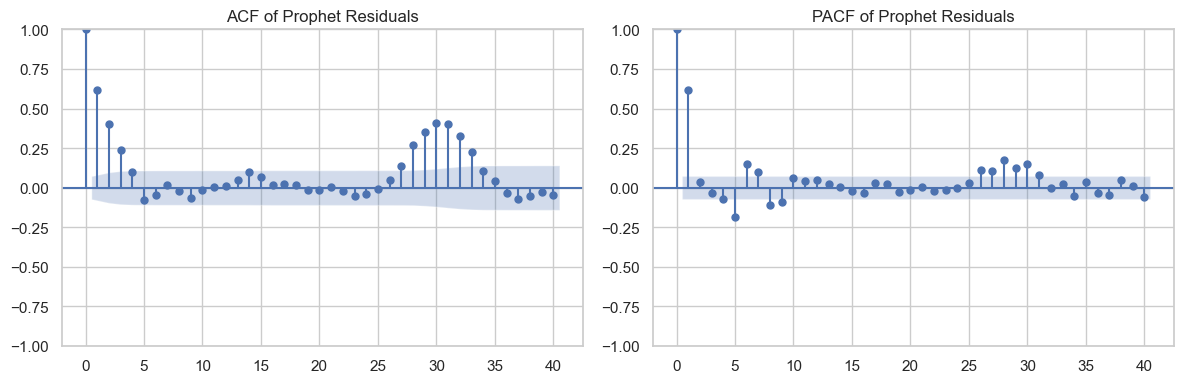

In [7]:
all_residuals = []

for i in range(len(all_y_true_log)):
    residual = (
        np.array(all_y_true_log[i])
        - np.array(all_y_pred_log[i])
    )
    all_residuals.extend(residual)

all_residuals = np.array(all_residuals)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1,2, figsize=(12,4))

plot_acf(all_residuals, lags=40, ax=ax[0])
ax[0].set_title("ACF of Prophet Residuals")

plot_pacf(all_residuals, lags=40, method='ywm', ax=ax[1])
ax[1].set_title("PACF of Prophet Residuals")

plt.tight_layout()
plt.show()

Residual Statistics
- Residual mean = 0.0440, gần bằng 0, cho thấy mô hình không có sai lệch hệ thống lớn.
- Residual phân phối tương đối cân đối (Skew = -0.1367), tuy nhiên vẫn tồn tại một số sai số lớn (Kurtosis = 0.6604).
- Durbin-Watson = 0.7676 (< 2) cho thấy dấu hiệu tự tương quan dương trong phần dư.

Ljung-Box Test
- Tất cả p-value tại các lag (5, 10, 15, 20, 30) đều < 0.05.
- Bác bỏ giả thuyết phần dư là độc lập.
- Residual vẫn chứa cấu trúc thời gian chưa được Prophet khai thác.

ADF Test
- Tất cả p-value < 0.05.
- Residual đạt tính dừng ở cả 4 folds.
- Prophet đã loại bỏ phần lớn xu hướng dài hạn của chuỗi doanh thu.

ACF & PACF Analysis
- ACF cho thấy tồn tại tự tương quan ngắn hạn và chu kỳ khoảng 1 tháng.
- PACF xuất hiện các đỉnh mạnh ở các lag đầu tiên, cho thấy cấu trúc AR bậc thấp.
- Residual chưa phải white noise hoàn toàn.

Conclusion
- Prophet DUAN đã xử lý được xu hướng và mùa vụ chính nhưng vẫn còn thông tin dự báo trong residual.
- Residual dừng nhưng còn tự tương quan đáng kể.
- Điều này tạo cơ sở cho việc xây dựng mô hình Hybrid Prophet + Machine Learning nhằm khai thác các đặc trưng lag, rolling window và các mẫu phụ thuộc thời gian còn sót lại.

#### 2.3 Phân tích pattern lỗi của mô hình Prophet DUAN

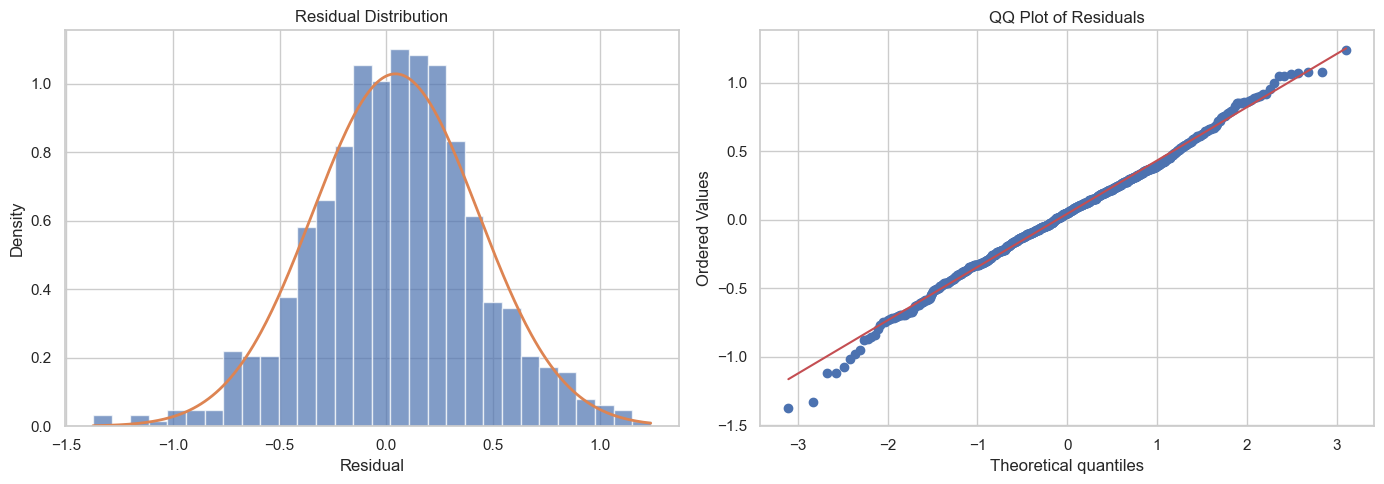

RESIDUAL DISTRIBUTION SUMMARY
Mean     : 0.0433
Std      : 0.3879
Skewness : -0.0883
Kurtosis : 0.4857


In [14]:
# =========================================================
# COMBINE RESIDUALS FROM ALL FOLDS
# =========================================================
import matplotlib.pyplot as plt
import scipy.stats as stats

all_residuals = []

for i in range(len(all_y_true_log)):

    residual_fold = (
        np.array(all_y_true_log[i])
        - np.array(all_y_pred_log[i])
    )

    all_residuals.extend(residual_fold)

all_residuals = np.array(all_residuals)

# =========================================================
# HISTOGRAM + QQ PLOT
# =========================================================

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax[0].hist(
    all_residuals,
    bins=30,
    density=True,
    alpha=0.7
)

# Overlay Normal Curve
mu = all_residuals.mean()
sigma = all_residuals.std()

x = np.linspace(
    all_residuals.min(),
    all_residuals.max(),
    300
)

ax[0].plot(
    x,
    stats.norm.pdf(x, mu, sigma),
    linewidth=2
)

ax[0].set_title("Residual Distribution")
ax[0].set_xlabel("Residual")
ax[0].set_ylabel("Density")

# QQ Plot
stats.probplot(
    all_residuals,
    dist="norm",
    plot=ax[1]
)

ax[1].set_title("QQ Plot of Residuals")

plt.tight_layout()
plt.show()

# =========================================================
# SUMMARY
# =========================================================

print("=" * 60)
print("RESIDUAL DISTRIBUTION SUMMARY")
print("=" * 60)
print(f"Mean     : {all_residuals.mean():.4f}")
print(f"Std      : {all_residuals.std():.4f}")
print(f"Skewness : {stats.skew(all_residuals):.4f}")
print(f"Kurtosis : {stats.kurtosis(all_residuals):.4f}")

- Residual mean = 0.0433, gần bằng 0, cho thấy Prophet DUAN không có sai lệch hệ thống đáng kể.
- Phân phối residual tương đối cân đối (Skew = -0.0883) và gần với phân phối chuẩn.
- QQ Plot cho thấy các điểm dữ liệu bám sát đường lý thuyết ở vùng trung tâm, phản ánh mức độ phù hợp tốt với giả định chuẩn.
- Tuy nhiên, phần đuôi trái lệch khỏi đường chuẩn, cho thấy vẫn tồn tại một số thời điểm xuất hiện sai số âm lớn mà mô hình chưa giải thích được.

**Insight:** Residual của Prophet DUAN nhìn chung ổn định và gần phân phối chuẩn, nhưng vẫn còn các ngoại lệ ở phần đuôi phân phối, hàm ý mô hình chưa nắm bắt hoàn toàn các biến động bất thường của doanh thu.

MONTHLY RESIDUAL ANALYSIS


,Month,Mean_Residual,Std_Residual,Observations
0,1,0.0115,0.4369,62
1,2,0.1637,0.4573,56
2,3,0.2428,0.3757,62
3,4,0.1517,0.3860,60
4,5,0.1028,0.3522,62
5,6,0.1219,0.3149,60
6,7,-0.0170,0.3773,62
7,8,-0.0132,0.4206,62
8,9,-0.0237,0.3493,60
9,10,-0.0295,0.3091,62


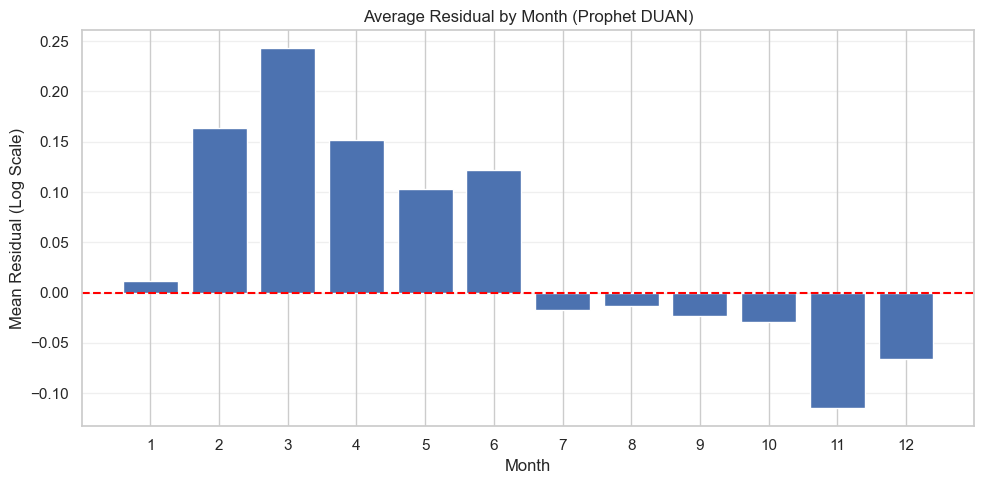

In [39]:
# =========================================================
# RESIDUAL SEASONAL PATTERN BY MONTH
# =========================================================

all_residual_rows = []

for i, split_info in enumerate(fold_splits):

    test_df = split_info["test"].copy()

    y_true_log = np.array(all_y_true_log[i])
    y_pred_log = np.array(all_y_pred_log[i])

    residuals = y_true_log - y_pred_log

    temp = pd.DataFrame({
        "Date": pd.to_datetime(test_df["ds"].values),
        "Residual": residuals
    })

    all_residual_rows.append(temp)

# =========================================================
# CONCAT ALL FOLDS
# =========================================================

residual_df = pd.concat(
    all_residual_rows,
    ignore_index=True
)

# =========================================================
# MONTHLY RESIDUAL
# =========================================================

residual_df["Month"] = residual_df["Date"].dt.month

monthly_residual = (
    residual_df
    .groupby("Month")["Residual"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

monthly_residual.columns = [
    "Month",
    "Mean_Residual",
    "Std_Residual",
    "Observations"
]

print("="*70)
print("MONTHLY RESIDUAL ANALYSIS")
print("="*70)

display(
    monthly_residual.round(4)
)

# =========================================================
# BAR CHART
# =========================================================

plt.figure(figsize=(10,5))

bars = plt.bar(
    monthly_residual["Month"],
    monthly_residual["Mean_Residual"]
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=1.5
)

plt.xticks(range(1,13))

plt.title(
    "Average Residual by Month (Prophet DUAN)"
)

plt.xlabel("Month")
plt.ylabel("Mean Residual (Log Scale)")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

- Residual mang giá trị **dương trong giai đoạn tháng 1–6**, đặc biệt cao nhất ở tháng 3, cho thấy Prophet có xu hướng **dự báo thấp hơn thực tế** trong quý I và chưa nắm bắt đầy đủ các đợt tăng doanh thu theo mùa vụ (Tết, lễ đầu năm).

- Residual chuyển sang **âm từ tháng 7–12**, với sai lệch lớn nhất vào tháng 11 và tháng 12, phản ánh mô hình **dự báo cao hơn thực tế nhẹ** trong nửa cuối năm.

- Độ lệch chuẩn residual tương đối ổn định giữa các tháng, cho thấy **mức độ phân tán sai số không thay đổi đáng kể theo mùa**.

- Sai lệch chủ yếu xuất hiện ở **giá trị trung bình của residual theo tháng**, thay vì phương sai, cho thấy vẫn tồn tại **seasonality theo tháng chưa được Prophet mô hình hóa đầy đủ**.

- Kết quả này gợi ý việc bổ sung các đặc trưng tháng (month features) hoặc cơ chế hiệu chỉnh theo mùa trong mô hình Hybrid có thể giúp cải thiện độ chính xác dự báo.

### 3. Tối ưu mô hình bằng hybrid Prophet+ML

In [8]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [9]:
returns["return_date"] = pd.to_datetime(returns["return_date"])
web_traffic["date"] = pd.to_datetime(web_traffic["date"])
inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"])
shipping["ship_date"] = pd.to_datetime(shipping["ship_date"])
shipping["delivery_date"] = pd.to_datetime(shipping["delivery_date"])


HYBRID FOLD 1


18:08:27 - cmdstanpy - INFO - Chain [1] start processing
18:08:28 - cmdstanpy - INFO - Chain [1] done processing


  LightGBM   | MAE=587,548 | RMSE=832,875 | R²=0.8072 | Smear=1.0032
  XGBoost    | MAE=592,733 | RMSE=825,987 | R²=0.8103 | Smear=1.0024
  CatBoost   | MAE=621,887 | RMSE=900,071 | R²=0.7748 | Smear=1.0111


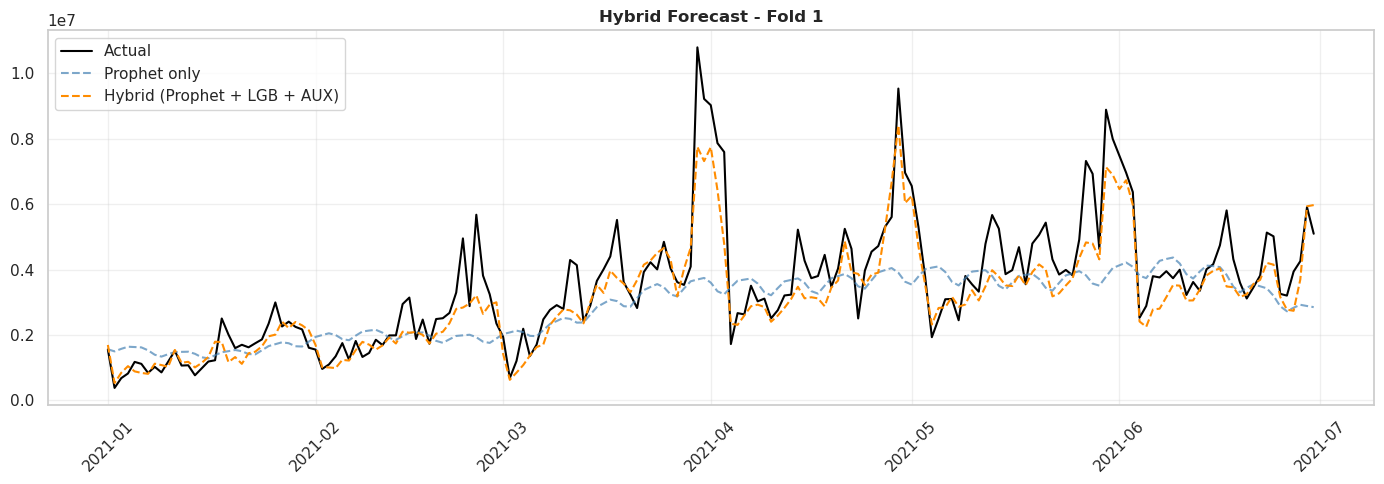


HYBRID FOLD 2


18:08:33 - cmdstanpy - INFO - Chain [1] start processing
18:08:33 - cmdstanpy - INFO - Chain [1] done processing


  LightGBM   | MAE=466,126 | RMSE=637,097 | R²=0.6027 | Smear=1.0034
  XGBoost    | MAE=462,090 | RMSE=626,692 | R²=0.6155 | Smear=1.0024
  CatBoost   | MAE=454,793 | RMSE=615,538 | R²=0.6291 | Smear=1.0113


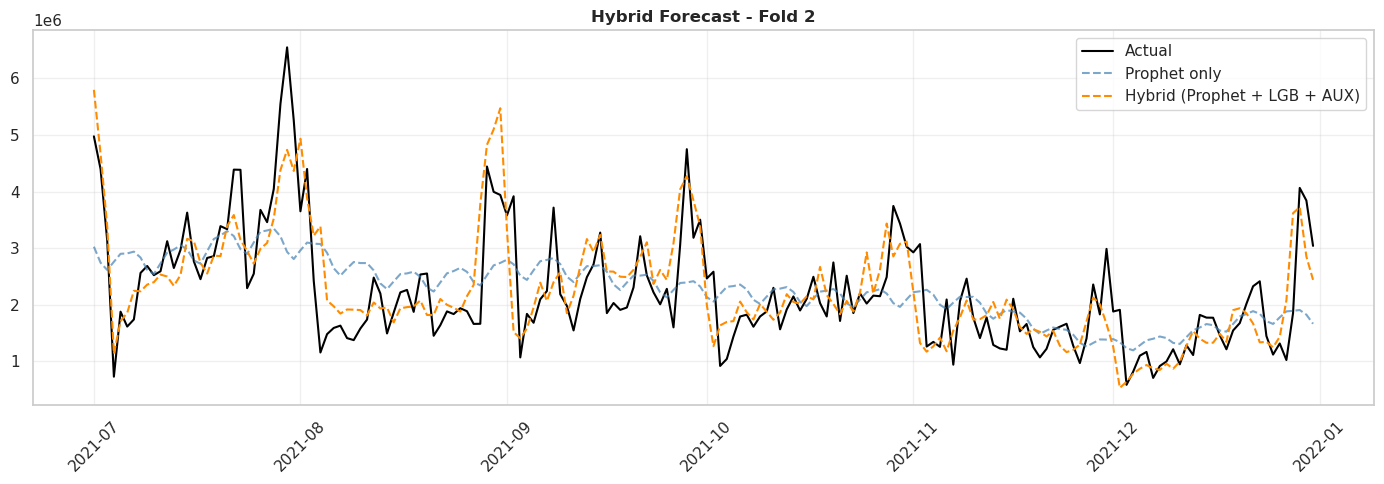


HYBRID FOLD 3


18:08:38 - cmdstanpy - INFO - Chain [1] start processing
18:08:39 - cmdstanpy - INFO - Chain [1] done processing


  LightGBM   | MAE=793,107 | RMSE=1,068,788 | R²=0.6561 | Smear=1.0039
  XGBoost    | MAE=766,730 | RMSE=1,019,089 | R²=0.6873 | Smear=1.0027
  CatBoost   | MAE=788,409 | RMSE=1,051,250 | R²=0.6673 | Smear=1.0123


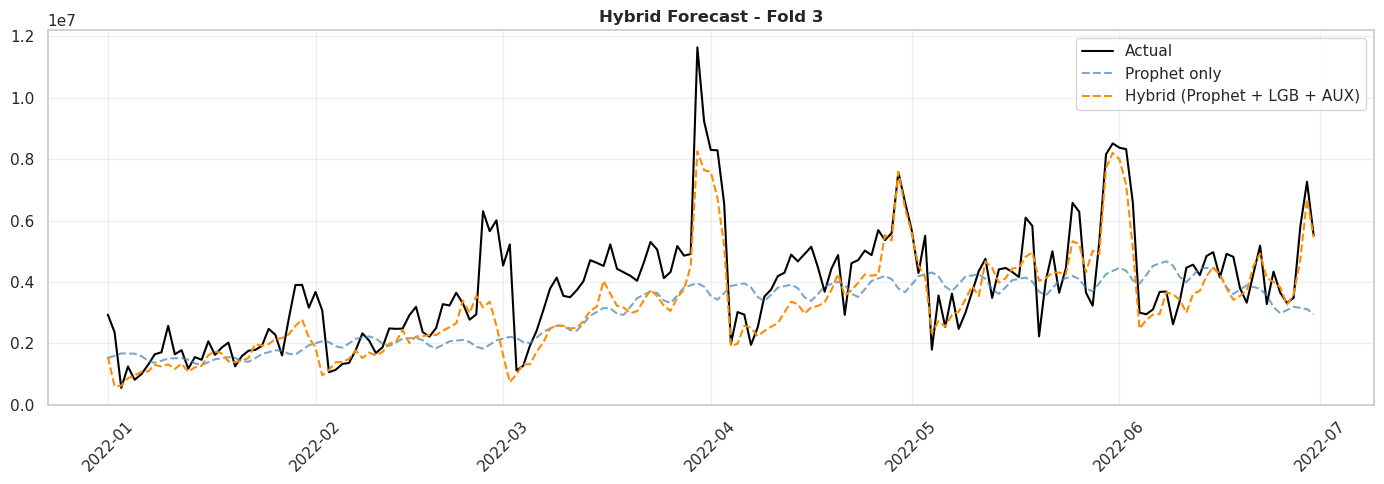


HYBRID FOLD 4


18:08:43 - cmdstanpy - INFO - Chain [1] start processing
18:08:44 - cmdstanpy - INFO - Chain [1] done processing


  LightGBM   | MAE=496,823 | RMSE=676,656 | R²=0.7022 | Smear=1.0042
  XGBoost    | MAE=479,964 | RMSE=664,483 | R²=0.7129 | Smear=1.0030
  CatBoost   | MAE=461,379 | RMSE=619,878 | R²=0.7501 | Smear=1.0129


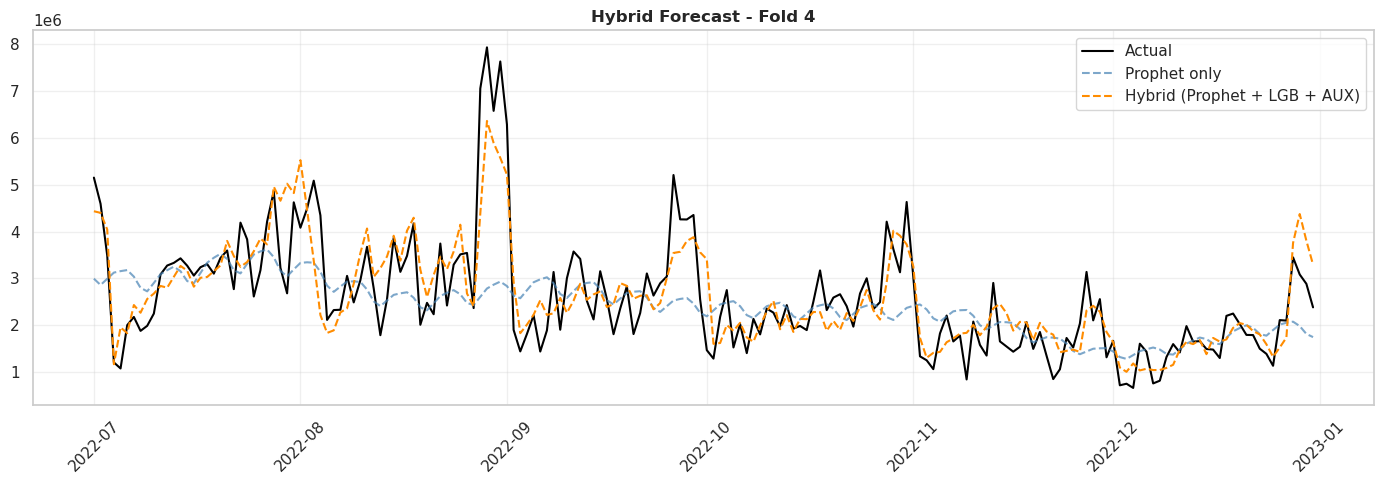


HYBRID RESULTS - ALL FOLDS


,Fold,Model,MAE,RMSE,R2,Adj_R2,Smear
0,1,Hybrid_Prophet+LightGBM,587548.27,832874.72,0.8072,0.7746,1.0032
1,1,Hybrid_Prophet+XGBoost,592733.29,825986.82,0.8103,0.7783,1.0024
2,1,Hybrid_Prophet+CatBoost,621886.80,900071.12,0.7748,0.7368,1.0111
3,2,Hybrid_Prophet+LightGBM,466125.83,637096.78,0.6027,0.5369,1.0034
4,2,Hybrid_Prophet+XGBoost,462089.64,626692.34,0.6155,0.5519,1.0024
5,2,Hybrid_Prophet+CatBoost,454793.18,615537.66,0.6291,0.5677,1.0113
6,3,Hybrid_Prophet+LightGBM,793107.35,1068787.86,0.6561,0.5981,1.0039
7,3,Hybrid_Prophet+XGBoost,766729.61,1019088.60,0.6873,0.6346,1.0027
8,3,Hybrid_Prophet+CatBoost,788409.36,1051249.51,0.6673,0.6111,1.0123
9,4,Hybrid_Prophet+LightGBM,496822.50,676656.19,0.7022,0.6529,1.0042



AVERAGE PERFORMANCE BY MODEL


,MAE,RMSE,R2,Adj_R2
Model,,,,
Hybrid_Prophet+XGBoost,575379.1150,784062.5975,0.7065,0.6575
Hybrid_Prophet+CatBoost,581617.1925,796684.1575,0.7053,0.6561
Hybrid_Prophet+LightGBM,585900.9875,803853.8875,0.6921,0.6406


In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# =========================================================
# THÊM HÀM APPLY AUX (giống standalone)
# =========================================================
def apply_aux_features(df, aux_tables):
    df = df.copy()

    df = df.merge(aux_tables["inv_m"], on="Month", how="left")
    df = df.merge(aux_tables["ret_md"], on=["Month", "Day"], how="left")
    df = df.merge(aux_tables["wt_md"], on=["Month", "Day"], how="left")
    df = df.merge(aux_tables["ship_md"], on=["Month", "Day"], how="left")

    return df


def engineer_features_from_ds(df):
    df = df.copy()
    df = df.rename(columns={"ds": "Date", "y": "Revenue"})
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.reset_index(drop=True)
    df["LogRevenue"] = df["Revenue"]  # y đã là log space, gán thẳng
    df = engineer_features(df)        # if guard sẽ skip log1p
    return df


# =========================================================
# CẬP NHẬT FEATURE LIST: THÊM AUX
# =========================================================
RESIDUAL_FEATURES = [
    # Time
    'Month', 'Day', 'DayOfWeek', 'DayOfYear',
    'Quarter', 'WeekOfYear', 'IsWeekend',
    # Fourier
    'doy_sin', 'doy_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
    # Lag/trend
    'lag_7', 'lag_14',
    'ma_7', 'ma_30', 'std_30',
    # AUX
    'inv_stockout', 'inv_fillrate', 'inv_sellthru',
    'returns_md',
    'sessions_md', 'visitors_md',
    'avg_ship_fee', 'avg_delivery_days',
]

# =========================================================
# MAIN LOOP: HYBRID + AUX
# =========================================================
# Map tên biến cho đúng với cell giữa


def get_models():
    return {
        'LightGBM': LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
            n_jobs=-1,
            verbose=-1,
        ),
        'XGBoost': XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            random_state=42,
            n_jobs=-1,
            verbosity=0,
        ),
        'CatBoost': CatBoostRegressor(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            random_state=42,
            verbose=0,
        ),
    }

df_inventory_cleaned   = inventory
df_returns_cleaned     = returns
df_web_traffic_cleaned = web_traffic
df_shipments_cleaned   = shipping
hybrid_results = []

for i, split in enumerate(fold_splits):

    fold      = split['fold']
    train_raw = split['train'].copy()   # ds, y (log space)
    test_raw  = split['test'].copy()

    print(f"\n{'='*70}")
    print(f"HYBRID FOLD {fold}")
    print(f"{'='*70}")

    # ---------------------------------------------------------
    # BƯỚC 1: PROPHET PREDICTION ĐÃ CÓ
    # ---------------------------------------------------------
    y_true_log    = all_y_true_log[i]
    y_prophet_log = all_y_pred_log[i]

    # ---------------------------------------------------------
    # BƯỚC 2: RE-RUN PROPHET TRÊN TRAIN → LẤY RESIDUAL
    # ---------------------------------------------------------
    from prophet import Prophet as _Prophet

    train_prophet = train_raw[['ds', 'y']].copy()
    train_prophet['ds'] = pd.to_datetime(train_prophet['ds'])

    _model = _Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.1,
        seasonality_mode='multiplicative'
    )
    _model.fit(train_prophet)

    forecast_train = _model.predict(
        _model.make_future_dataframe(periods=0, freq='D')
    )
    forecast_train = forecast_train[['ds', 'yhat']].merge(
        train_prophet, on='ds', how='inner'
    )

    prophet_residual_train = (
        forecast_train['y'].values
        - forecast_train['yhat'].values
    )

    # ---------------------------------------------------------
    # BƯỚC 3: BUILD AUX TABLES (chỉ dùng data <= train_end)
    # ---------------------------------------------------------
    train_end = pd.to_datetime(train_raw['ds'].max())

    aux_tables = build_aux_features(
        inventory_train=df_inventory_cleaned[
            df_inventory_cleaned["snapshot_date"] <= train_end
        ],
        returns_train=df_returns_cleaned[
            df_returns_cleaned["return_date"] <= train_end
        ],
        web_train=df_web_traffic_cleaned[
            df_web_traffic_cleaned["date"] <= train_end
        ],
        shipments_train=df_shipments_cleaned[
            df_shipments_cleaned["ship_date"] <= train_end
        ]
    )

    # ---------------------------------------------------------
    # BƯỚC 4: FEATURE ENGINEERING + APPLY AUX
    # ---------------------------------------------------------
    train_fe = engineer_features_from_ds(train_raw)
    test_fe  = engineer_features_from_ds(
        pd.concat([train_raw, test_raw], ignore_index=True)
    ).tail(len(test_raw)).reset_index(drop=True)

    # Thêm cột Month, Day cho merge (engineer_features_from_ds đã tạo rồi)
    train_fe = apply_aux_features(train_fe, aux_tables)
    test_fe  = apply_aux_features(test_fe,  aux_tables)

    # Align với prophet_residual_train
    train_fe = train_fe.tail(len(prophet_residual_train)).reset_index(drop=True)

    # Clean NaN/inf
    train_fe[RESIDUAL_FEATURES] = (
        train_fe[RESIDUAL_FEATURES]
        .replace([np.inf, -np.inf], np.nan)
    )
    test_fe[RESIDUAL_FEATURES] = (
        test_fe[RESIDUAL_FEATURES]
        .replace([np.inf, -np.inf], np.nan)
    )

    fill_vals = train_fe[RESIDUAL_FEATURES].median()
    X_train = train_fe[RESIDUAL_FEATURES].fillna(fill_vals)
    X_test  = test_fe[RESIDUAL_FEATURES].fillna(fill_vals)
    y_residual_train = prophet_residual_train[-len(X_train):]

    # ---------------------------------------------------------
    # BƯỚC 5: TRAIN ML → PREDICT RESIDUAL
    # ---------------------------------------------------------
    models = get_models()

    for model_name, ml_model in models.items():

        ml_model.fit(X_train, y_residual_train)

        residual_pred_test  = ml_model.predict(X_test)
        residual_pred_train = ml_model.predict(X_train)

        # ---------------------------------------------------------
        # BƯỚC 6: CỘNG → FINAL LOG PRED
        # ---------------------------------------------------------
        final_pred_log = y_prophet_log + residual_pred_test

        # ---------------------------------------------------------
        # BƯỚC 7: DUAN SMEARING TRÊN COMBINED
        # ---------------------------------------------------------
        combined_train_log = (
            forecast_train['yhat'].values[-len(X_train):]
            + residual_pred_train
        )
        train_true_log = forecast_train['y'].values[-len(X_train):]

        smear = np.mean(np.exp(train_true_log - combined_train_log))

        final_pred_rev = np.exp(final_pred_log) * smear
        y_true_rev     = np.expm1(y_true_log)

        # ---------------------------------------------------------
        # BƯỚC 8: EVALUATE
        # ---------------------------------------------------------
        mae    = mean_absolute_error(y_true_rev, final_pred_rev)
        rmse   = np.sqrt(mean_squared_error(y_true_rev, final_pred_rev))
        r2     = r2_score(y_true_rev, final_pred_rev)
        n, p   = len(y_true_rev), len(RESIDUAL_FEATURES)
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

        print(
            f"  {model_name:<10}"
            f" | MAE={mae:,.0f}"
            f" | RMSE={rmse:,.0f}"
            f" | R²={r2:.4f}"
            f" | Smear={smear:.4f}"
        )

        hybrid_results.append({
            'Fold':    fold,
            'Model':   f"Hybrid_Prophet+{model_name}",
            'MAE':     round(mae, 2),
            'RMSE':    round(rmse, 2),
            'R2':      round(r2, 4),
            'Adj_R2':  round(adj_r2, 4),
            'Smear':   round(smear, 4),
        })

    # ---------------------------------------------------------
    # PLOT: Actual vs Prophet vs Hybrid LightGBM
    # ---------------------------------------------------------
    lgb_plot = get_models()['LightGBM']
    lgb_plot.fit(X_train, y_residual_train)
    final_lgb_rev = np.exp(y_prophet_log + lgb_plot.predict(X_test)) * smear

    plt.figure(figsize=(14, 5))
    plt.plot(test_raw['ds'].values, y_true_rev,
             label='Actual', color='black')
    plt.plot(test_raw['ds'].values, np.expm1(y_prophet_log),
             '--', label='Prophet only', color='steelblue', alpha=0.7)
    plt.plot(test_raw['ds'].values, final_lgb_rev,
             '--', label='Hybrid (Prophet + LGB + AUX)', color='darkorange')
    plt.title(f'Hybrid Forecast - Fold {fold}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# =========================================================
# SUMMARY
# =========================================================
hybrid_df = pd.DataFrame(hybrid_results)

print("\n" + "="*70)
print("HYBRID RESULTS - ALL FOLDS")
print("="*70)
display(hybrid_df)

print("\n" + "="*70)
print("AVERAGE PERFORMANCE BY MODEL")
print("="*70)
summary = (
    hybrid_df
    .groupby('Model')[['MAE', 'RMSE', 'R2', 'Adj_R2']]
    .mean()
    .round(4)
    .sort_values('RMSE')
)
display(summary)

Hybrid_Prophet+XGBoost đạt kết quả tốt nhất với MAE và RMSE thấp nhất, đồng thời có R² cao nhất so với các mô hình còn lại.  

Nhìn chung, các mô hình Hybrid cho hiệu suất khá ổn định, trong đó XGBoost thể hiện khả năng học phần dư tốt hơn CatBoost và LightGBM.

Saving to: D:\KienTap_RevenueEcommerce\revenue_forecast_ecommerce\notebooks\outputs\figures\model

SHAP - Hybrid Fold 1


18:16:52 - cmdstanpy - INFO - Chain [1] start processing
18:16:53 - cmdstanpy - INFO - Chain [1] done processing


      group  importance        pct  fold
0       AUX    0.055797  11.505381     1
1   Fourier    0.073065  15.066128     1
2  LagTrend    0.148998  30.723560     1
3      Time    0.207103  42.704941     1

SHAP - Hybrid Fold 2


18:16:56 - cmdstanpy - INFO - Chain [1] start processing
18:16:56 - cmdstanpy - INFO - Chain [1] done processing


      group  importance        pct  fold
0       AUX    0.061113  12.468806     2
1   Fourier    0.067710  13.814696     2
2  LagTrend    0.152379  31.089655     2
3      Time    0.208927  42.626842     2

SHAP - Hybrid Fold 3


...

      group  importance        pct  fold
0       AUX    0.056108  11.563749     3
1   Fourier    0.069019  14.224651     3
2  LagTrend    0.152212  31.370518     3
3      Time    0.207867  42.841080     3

SHAP - Hybrid Fold 4


18:17:04 - cmdstanpy - INFO - Chain [1] start processing
18:17:05 - cmdstanpy - INFO - Chain [1] done processing


      group  importance        pct  fold
0       AUX    0.053108  11.085994     4
1   Fourier    0.067820  14.156980     4
2  LagTrend    0.151761  31.679186     4
3      Time    0.206367  43.077839     4

SHAP GROUP IMPORTANCE - HYBRID (XGBOOST)


,mean,std
group,,
Time,42.812675,0.197703
LagTrend,31.215729,0.406971
Fourier,14.315614,0.531548
AUX,11.655983,0.582168



Saved → outputs\figures\model\shap_group_importance_xgboost_hybrid.png


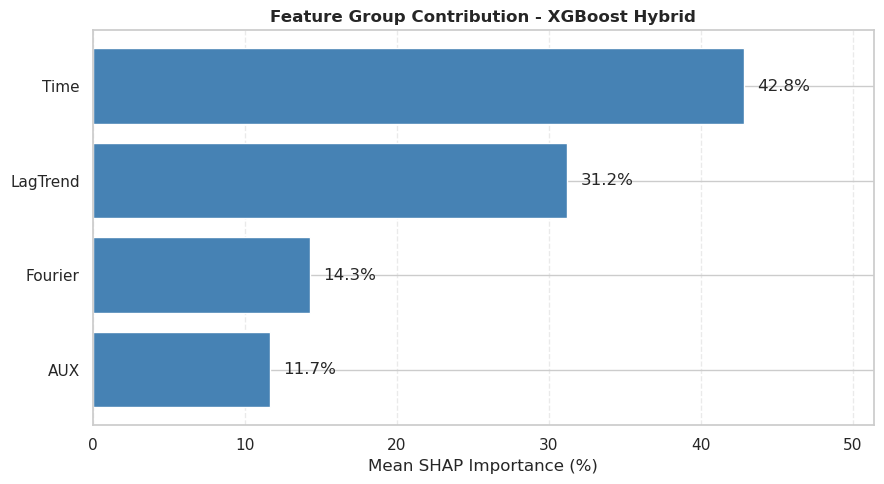

In [38]:
# =========================================================
# SHAP FEATURE GROUP IMPORTANCE - HYBRID MODEL (XGBOOST)
# =========================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from xgboost import XGBRegressor

FIG_DIR = Path("outputs/figures/model")
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Saving to: {FIG_DIR.resolve()}")  # in ra absolute path thực tế

all_group_importance_hybrid = []

for i, split in enumerate(fold_splits):

    fold      = split['fold']
    train_raw = split['train'].copy()

    print("\n" + "="*60)
    print(f"SHAP - Hybrid Fold {fold}")
    print("="*60)

    # ====================================
    # BUILD AUX TABLES
    # ====================================
    train_end = pd.to_datetime(train_raw['ds'].max())

    aux_tables = build_aux_features(
        inventory_train=df_inventory_cleaned[
            df_inventory_cleaned["snapshot_date"] <= train_end
        ],
        returns_train=df_returns_cleaned[
            df_returns_cleaned["return_date"] <= train_end
        ],
        web_train=df_web_traffic_cleaned[
            df_web_traffic_cleaned["date"] <= train_end
        ],
        shipments_train=df_shipments_cleaned[
            df_shipments_cleaned["ship_date"] <= train_end
        ]
    )

    # ====================================
    # FEATURE ENGINEERING
    # ====================================
    train_fe = engineer_features_from_ds(train_raw)
    train_fe = apply_aux_features(train_fe, aux_tables)

    # ====================================
    # TRAIN PROPHET (for residuals)
    # ====================================
    from prophet import Prophet as _Prophet

    train_prophet = train_raw[['ds', 'y']].copy()
    train_prophet['ds'] = pd.to_datetime(train_prophet['ds'])

    _model = _Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.1,
        seasonality_mode='multiplicative'
    )

    _model.fit(train_prophet)

    forecast_train = _model.predict(
        _model.make_future_dataframe(periods=0, freq='D')
    )

    forecast_train = forecast_train[['ds', 'yhat']].merge(
        train_prophet, on='ds', how='inner'
    )

    prophet_residual_train = (
        forecast_train['y'].values - forecast_train['yhat'].values
    )

    # ====================================
    # ALIGN FEATURES
    # ====================================
    train_fe = train_fe.tail(len(prophet_residual_train)).reset_index(drop=True)

    train_fe[RESIDUAL_FEATURES] = (
        train_fe[RESIDUAL_FEATURES]
        .replace([np.inf, -np.inf], np.nan)
    )

    fill_vals = train_fe[RESIDUAL_FEATURES].median()
    X_train = train_fe[RESIDUAL_FEATURES].fillna(fill_vals)
    y_resid = prophet_residual_train[-len(X_train):]

    # ====================================
    # XGBOOST MODEL
    # ====================================
    xgb_hybrid = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )

    xgb_hybrid.fit(X_train, y_resid)

    # ====================================
    # SHAP VALUES
    # ====================================
    explainer = shap.TreeExplainer(xgb_hybrid)
    shap_vals = explainer.shap_values(X_train)

    mean_abs_shap = np.abs(shap_vals).mean(axis=0)

    shap_df = pd.DataFrame({
        "feature":    RESIDUAL_FEATURES,
        "importance": mean_abs_shap,
    })

    # ====================================
    # FEATURE GROUP MAP
    # ====================================
    feature_group_map = {
        # Time
        'Month': 'Time', 'Day': 'Time', 'DayOfWeek': 'Time',
        'DayOfYear': 'Time', 'Quarter': 'Time',
        'WeekOfYear': 'Time', 'IsWeekend': 'Time',

        # Fourier
        'doy_sin': 'Fourier', 'doy_cos': 'Fourier',
        'dow_sin': 'Fourier', 'dow_cos': 'Fourier',
        'month_sin': 'Fourier', 'month_cos': 'Fourier',

        # Lag/Trend
        'lag_7': 'LagTrend', 'lag_14': 'LagTrend',
        'ma_7': 'LagTrend', 'ma_30': 'LagTrend', 'std_30': 'LagTrend',

        # AUX
        'inv_stockout': 'AUX', 'inv_fillrate': 'AUX',
        'inv_sellthru': 'AUX', 'returns_md': 'AUX',
        'sessions_md': 'AUX', 'visitors_md': 'AUX',
        'avg_ship_fee': 'AUX', 'avg_delivery_days': 'AUX',
    }

    shap_df["group"] = (
        shap_df["feature"]
        .map(feature_group_map)
        .fillna("Other")
    )

    group_imp = (
        shap_df
        .groupby("group", as_index=False)["importance"]
        .sum()
    )

    group_imp["pct"] = (
        group_imp["importance"] /
        group_imp["importance"].sum() * 100
    )

    group_imp["fold"] = fold

    all_group_importance_hybrid.append(group_imp)

    print(group_imp)


# =========================================================
# AGGREGATE ACROSS FOLDS
# =========================================================
group_imp_hybrid_df = pd.concat(all_group_importance_hybrid, ignore_index=True)

summary_hybrid = (
    group_imp_hybrid_df
    .groupby("group")["pct"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
)

print("\n" + "="*60)
print("SHAP GROUP IMPORTANCE - HYBRID (XGBOOST)")
print("="*60)

display(summary_hybrid)


# =========================================================
# PLOT + SAVE
# =========================================================
group_summary_hybrid = (
    summary_hybrid
    .reset_index()
    .rename(columns={"mean": "pct"})
    .sort_values("pct", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    group_summary_hybrid["group"],
    group_summary_hybrid["pct"],
    color="steelblue",
)

ax.set_xlabel("Mean SHAP Importance (%)")
ax.set_title("Feature Group Contribution - XGBoost Hybrid")

max_pct = group_summary_hybrid["pct"].max()
ax.set_xlim(0, max_pct * 1.2)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + max_pct * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
    )

ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()

# Lưu file
save_path = FIG_DIR / "shap_group_importance_xgboost_hybrid.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"\nSaved → {save_path}")

plt.show()

**Time features chiếm tỷ trọng cao nhất (42.8%)**, cho thấy XGBoost dựa chủ yếu vào các tín hiệu lịch (tháng, ngày, thứ) để học phần dư sau Prophet — hợp lý vì Prophet đã xử lý trend dài hạn, phần còn lại vẫn mang tính mùa vụ rõ nét.

**LagTrend đứng thứ hai (31.2%)** với độ ổn định cao nhất (std thấp nhất 0.41), trong khi AUX chỉ đóng góp 11.7% - gợi ý rằng các feature ngoại sinh (tồn kho, web traffic, vận chuyển) bổ sung tín hiệu có ích nhưng chưa phải yếu tố quyết định trong residual modeling.

### 4. Tối ưu mô hình bằng ML độc lập

In [28]:
# =========================================================
# TẠO FOLDS CHO ML
# =========================================================

fold_splits = create_expanding_window_splits(stl_df)

folds = []

for split in fold_splits:

    train_raw = split["train"].copy()   # cột: ds, y
    test_raw  = split["test"].copy()    # cột: ds, y

    # Rename ds → Date, y → LogRevenue
    for df_ in [train_raw, test_raw]:
        df_.rename(columns={"ds": "Date", "y": "LogRevenue"}, inplace=True)
        df_["Date"]    = pd.to_datetime(df_["Date"])
        df_["Revenue"] = np.expm1(df_["LogRevenue"])

    # Engineer features (Time + Fourier + Lag)
    # Concat train+test để lag features không bị NaN ở đầu test
    combined = pd.concat([train_raw, test_raw], ignore_index=True)
    combined = engineer_features(combined)

    train_fe = combined.iloc[:len(train_raw)].reset_index(drop=True)
    test_fe  = combined.iloc[len(train_raw):].reset_index(drop=True)

    folds.append({
        "fold":  split["fold"],
        "train": train_fe,
        "test":  test_fe,
    })

print(f" Đã tạo {len(folds)} folds")
for f in folds:
    print(
        f"  Fold {f['fold']}"
        f" | Train: {f['train']['Date'].min().date()} → {f['train']['Date'].max().date()}"
        f" ({len(f['train'])} rows)"
        f" | Test: {f['test']['Date'].min().date()} → {f['test']['Date'].max().date()}"
        f" ({len(f['test'])} rows)"
    )


FOLD 1
Train : 2012-07-04 -> 2020-12-31 | Size = 3103
Test  : 2021-01-01 -> 2021-06-30 | Size = 181

FOLD 2
Train : 2012-07-04 -> 2021-06-30 | Size = 3284
Test  : 2021-07-01 -> 2021-12-31 | Size = 184

FOLD 3
Train : 2012-07-04 -> 2021-12-31 | Size = 3468
Test  : 2022-01-01 -> 2022-06-30 | Size = 181

FOLD 4
Train : 2012-07-04 -> 2022-06-30 | Size = 3649
Test  : 2022-07-01 -> 2022-12-31 | Size = 184
 Đã tạo 4 folds
  Fold 1 | Train: 2012-07-04 → 2020-12-31 (3103 rows) | Test: 2021-01-01 → 2021-06-30 (181 rows)
  Fold 2 | Train: 2012-07-04 → 2021-06-30 (3284 rows) | Test: 2021-07-01 → 2021-12-31 (184 rows)
  Fold 3 | Train: 2012-07-04 → 2021-12-31 (3468 rows) | Test: 2022-01-01 → 2022-06-30 (181 rows)
  Fold 4 | Train: 2012-07-04 → 2022-06-30 (3649 rows) | Test: 2022-07-01 → 2022-12-31 (184 rows)



  FOLD 1  |  Train: 2012-07-04 → 2020-12-31
             |  Test : 2021-01-01 → 2021-06-30
  LightGBM   | RMSE=     734,746 | MAE=     521,771 | R²= 0.8499 | AdjR²= 0.8211 | Smear=1.0032
  XGBoost    | RMSE=     769,448 | MAE=     552,287 | R²= 0.8354 | AdjR²= 0.8038 | Smear=1.0021
  CatBoost   | RMSE=     731,221 | MAE=     508,771 | R²= 0.8514 | AdjR²= 0.8228 | Smear=1.0109


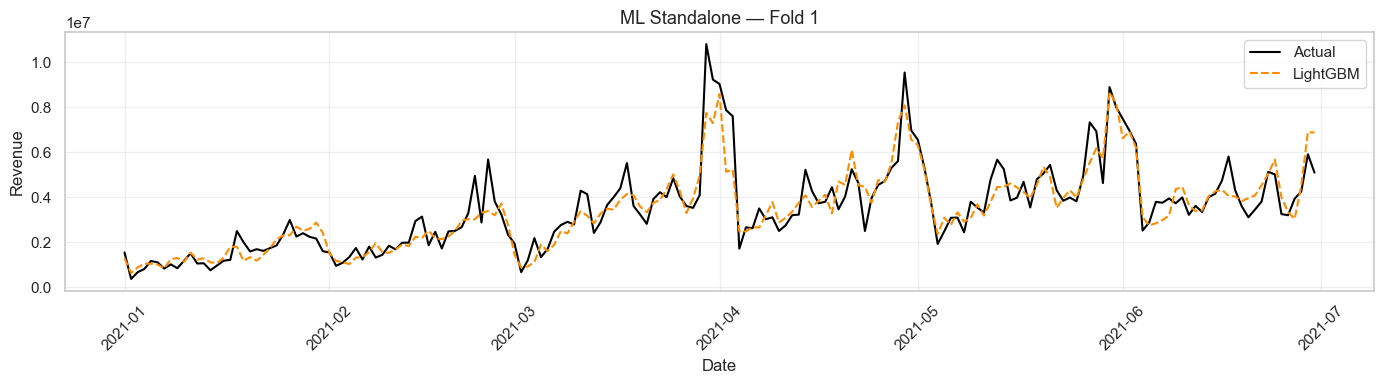


  FOLD 2  |  Train: 2012-07-04 → 2021-06-30
             |  Test : 2021-07-01 → 2021-12-31
  LightGBM   | RMSE=     665,053 | MAE=     488,865 | R²= 0.5670 | AdjR²= 0.4855 | Smear=1.0034
  XGBoost    | RMSE=     631,630 | MAE=     458,716 | R²= 0.6095 | AdjR²= 0.5359 | Smear=1.0023
  CatBoost   | RMSE=     597,495 | MAE=     433,211 | R²= 0.6505 | AdjR²= 0.5847 | Smear=1.0111


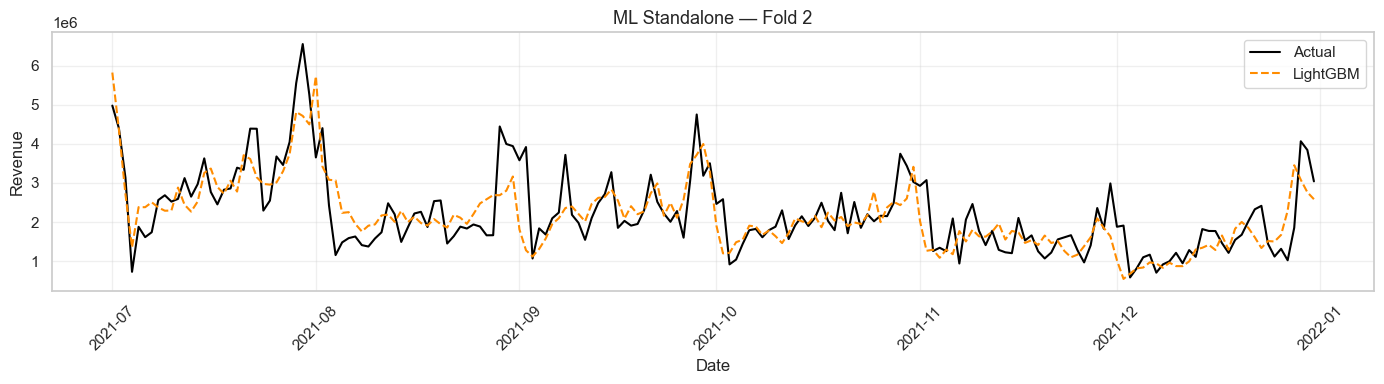


  FOLD 3  |  Train: 2012-07-04 → 2021-12-31
             |  Test : 2022-01-01 → 2022-06-30
  LightGBM   | RMSE=     865,970 | MAE=     618,921 | R²= 0.7742 | AdjR²= 0.7309 | Smear=1.0039
  XGBoost    | RMSE=     861,816 | MAE=     620,465 | R²= 0.7764 | AdjR²= 0.7335 | Smear=1.0027
  CatBoost   | RMSE=     886,221 | MAE=     647,472 | R²= 0.7636 | AdjR²= 0.7182 | Smear=1.0120


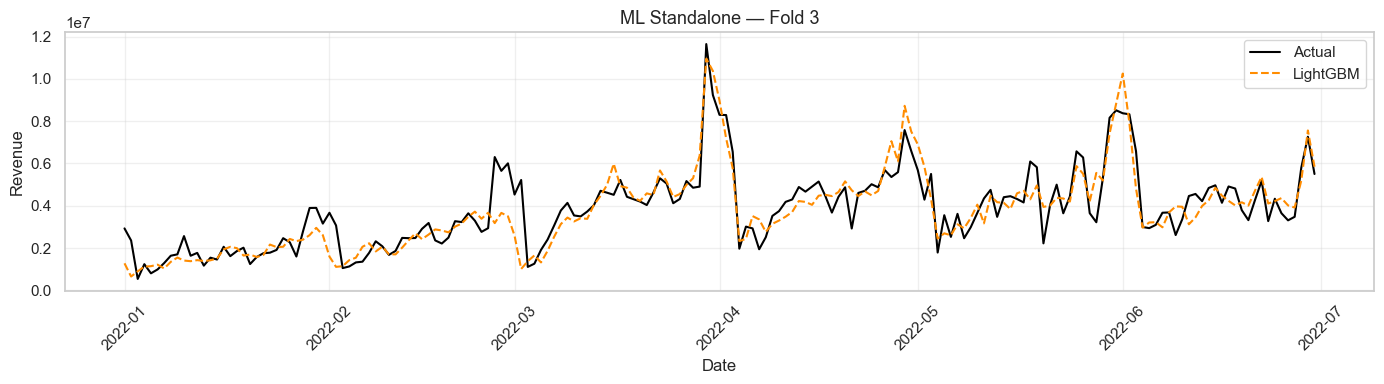


  FOLD 4  |  Train: 2012-07-04 → 2022-06-30
             |  Test : 2022-07-01 → 2022-12-31
  LightGBM   | RMSE=     667,204 | MAE=     493,725 | R²= 0.7105 | AdjR²= 0.6560 | Smear=1.0045
  XGBoost    | RMSE=     656,921 | MAE=     484,602 | R²= 0.7194 | AdjR²= 0.6665 | Smear=1.0028
  CatBoost   | RMSE=     650,390 | MAE=     464,873 | R²= 0.7249 | AdjR²= 0.6731 | Smear=1.0126


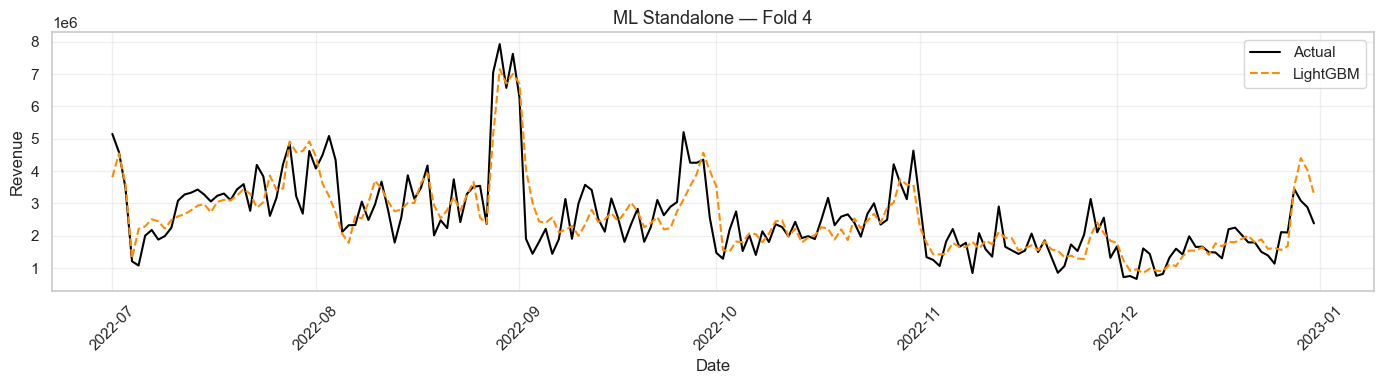


  ML STANDALONE — ALL FOLDS


,Fold,Model,RMSE,MAE,R2,Adj_R2,Smear
0,1,LightGBM,734745.53,521770.68,0.8499,0.8211,1.0032
1,1,XGBoost,769447.77,552286.64,0.8354,0.8038,1.0021
2,1,CatBoost,731220.62,508770.97,0.8514,0.8228,1.0109
3,2,LightGBM,665053.43,488864.67,0.5670,0.4855,1.0034
4,2,XGBoost,631630.09,458715.86,0.6095,0.5359,1.0023
5,2,CatBoost,597495.39,433211.00,0.6505,0.5847,1.0111
6,3,LightGBM,865970.12,618920.58,0.7742,0.7309,1.0039
7,3,XGBoost,861816.16,620464.93,0.7764,0.7335,1.0027
8,3,CatBoost,886221.15,647472.45,0.7636,0.7182,1.0120
9,4,LightGBM,667203.87,493724.93,0.7105,0.6560,1.0045



  AVERAGE PERFORMANCE BY MODEL (sorted by RMSE)


,MAE,RMSE,R2,Adj_R2
Model,,,,
CatBoost,513581.9125,716331.8875,0.7476,0.6997
XGBoost,529017.2950,729953.8475,0.7352,0.6849
LightGBM,530820.2150,733243.2375,0.7254,0.6734


In [22]:
# =========================================================
# ML ENSEMBLE STANDALONE - COMPLETE
# =========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# =========================================================
# FEATURE LIST - 4 NHÓM
# =========================================================
FEATURES = [
    # =====================================
    # THỜI GIAN / TIME (8)
    # =====================================
    'Month',
    'Day',
    'DayOfWeek',
    'DayOfYear',
    'Quarter',
    'WeekOfYear',
    'IsWeekend',
    'IsOddYear',

    # =====================================
    # FOURIER (8)
    # =====================================
    'doy_sin',
    'doy_cos',
    'dom_sin',
    'dom_cos',
    'dow_sin',
    'dow_cos',
    'month_sin',
    'month_cos',

    # =====================================
    # TRẺ & XU HƯỚNG / LAG + TREND (5)
    # =====================================
    'lag_7',
    'lag_14',
    'ma_7',
    'ma_30',
    'std_30',

    # =====================================
    # BIẾN BỔ SUNG / AUX (8)
    # =====================================
    'inv_stockout',
    'inv_fillrate',
    'inv_sellthru',
    'returns_md',
    'sessions_md',
    'visitors_md',
    'avg_ship_fee',
    'avg_delivery_days',
]


# =========================================================
# HELPERS
# =========================================================

def adjusted_r2(r2, n, p):
    if n <= p + 1:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


def apply_aux_features(df, aux_tables):
    df = df.copy()
    df = df.merge(aux_tables["inv_m"],   on="Month",          how="left")
    df = df.merge(aux_tables["ret_md"],  on=["Month", "Day"], how="left")
    df = df.merge(aux_tables["wt_md"],   on=["Month", "Day"], how="left")
    df = df.merge(aux_tables["ship_md"], on=["Month", "Day"], how="left")
    return df


def get_models():
    return {
        'LightGBM': LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
            n_jobs=-1,
            verbose=-1,
        ),
        'XGBoost': XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            random_state=42,
            n_jobs=-1,
            verbosity=0,
        ),
        'CatBoost': CatBoostRegressor(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            random_state=42,
            verbose=0,
        ),
    }

# =========================================================
# MAIN LOOP
# =========================================================

results    = []
fold_preds = {}

for fold in folds:

    fold_id  = fold["fold"]
    train_df = fold["train"].copy()
    test_df  = fold["test"].copy()

    print(f"\n{'='*65}")
    print(f"  FOLD {fold_id}  |  Train: {train_df['Date'].min().date()} → {train_df['Date'].max().date()}")
    print(f"             |  Test : {test_df['Date'].min().date()} → {test_df['Date'].max().date()}")
    print(f"{'='*65}")

    # --------------------------------------------------
    # 1. BUILD AUX TABLES (chỉ dùng data <= train_end)
    # --------------------------------------------------
    train_end = train_df["Date"].max()

    aux_tables = build_aux_features(
        inventory_train = df_inventory_cleaned[
            df_inventory_cleaned["snapshot_date"] <= train_end],
        returns_train   = df_returns_cleaned[
            df_returns_cleaned["return_date"]     <= train_end],
        web_train       = df_web_traffic_cleaned[
            df_web_traffic_cleaned["date"]        <= train_end],
        shipments_train = df_shipments_cleaned[
            df_shipments_cleaned["ship_date"]     <= train_end],
    )

    # --------------------------------------------------
    # 2. APPLY AUX FEATURES
    # --------------------------------------------------
    train_df = apply_aux_features(train_df, aux_tables)
    test_df  = apply_aux_features(test_df,  aux_tables)

    # --------------------------------------------------
    # 3. CLEAN NaN / INF
    # --------------------------------------------------
    for df_ in [train_df, test_df]:
        df_[FEATURES] = df_[FEATURES].replace([np.inf, -np.inf], np.nan)

    fill_values = train_df[FEATURES].median()

    train_df[FEATURES] = train_df[FEATURES].fillna(fill_values)
    test_df[FEATURES]  = test_df[FEATURES].fillna(fill_values)

    # --------------------------------------------------
    # 4. PREPARE X / y
    # --------------------------------------------------
    X_train     = train_df[FEATURES]
    X_test      = test_df[FEATURES]
    y_train_log = train_df["LogRevenue"]   # log1p space
    y_test_real = test_df["Revenue"]       # original space

    fold_preds[fold_id] = {
        "dates":  test_df["Date"].values,
        "y_true": y_test_real.values,
    }

    # --------------------------------------------------
    # 5. TRAIN EACH MODEL
    # --------------------------------------------------
    models = get_models()

    for name, model in models.items():

        # Fit
        model.fit(X_train, y_train_log)

        # Predict log space
        pred_log       = model.predict(X_test)
        train_pred_log = model.predict(X_train)

        # Duan Smearing — bias correction cho log transform
        residuals    = y_train_log.values - train_pred_log
        smear_factor = np.mean(np.exp(residuals))

        # Back-transform: LogRevenue = log1p → Revenue = expm1
        pred_rev = np.expm1(pred_log) * smear_factor
        pred_rev = np.maximum(pred_rev, 0)

        # Metrics
        rmse   = np.sqrt(mean_squared_error(y_test_real, pred_rev))
        mae    = mean_absolute_error(y_test_real, pred_rev)
        r2     = r2_score(y_test_real, pred_rev)
        adj_r2 = adjusted_r2(r2, len(y_test_real), len(FEATURES))

        print(
            f"  {name:<10}"
            f" | RMSE={rmse:>12,.0f}"
            f" | MAE={mae:>12,.0f}"
            f" | R²={r2:>7.4f}"
            f" | AdjR²={adj_r2:>7.4f}"
            f" | Smear={smear_factor:.4f}"
        )

        results.append({
            "Fold":   fold_id,
            "Model":  name,
            "RMSE":   round(rmse, 2),
            "MAE":    round(mae, 2),
            "R2":     round(r2, 4),
            "Adj_R2": round(adj_r2, 4),
            "Smear":  round(smear_factor, 4),
        })

        if name == "LightGBM":
            fold_preds[fold_id]["lgb_pred"] = pred_rev

    # --------------------------------------------------
    # 6. PLOT: Actual vs LightGBM
    # --------------------------------------------------
    fp = fold_preds[fold_id]

    plt.figure(figsize=(14, 4))
    plt.plot(fp["dates"], fp["y_true"],
             label="Actual", color="black", linewidth=1.5)
    plt.plot(fp["dates"], fp["lgb_pred"],
             label="LightGBM", color="darkorange",
             linewidth=1.5, linestyle="--")
    plt.title(f"ML Standalone — Fold {fold_id}", fontsize=13)
    plt.xlabel("Date")
    plt.ylabel("Revenue")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"ml_standalone_fold{fold_id}.png", dpi=150)
    plt.show()

# =========================================================
# SUMMARY
# =========================================================

results_df = pd.DataFrame(results)

print("\n" + "="*65)
print("  ML STANDALONE — ALL FOLDS")
print("="*65)
display(results_df)

print("\n" + "="*65)
print("  AVERAGE PERFORMANCE BY MODEL (sorted by RMSE)")
print("="*65)

summary = (
    results_df
    .groupby("Model")[["MAE", "RMSE", "R2", "Adj_R2"]]
    .mean()
    .round(4)
    .sort_values("RMSE")
)
display(summary)


- **CatBoost**: Tốt nhất với MAE và RMSE thấp nhất, đồng thời R² cao nhất (0.7476) → mô hình ổn định và chính xác nhất.
- **XGBoost**: Hiệu suất đứng thứ hai, sai số tăng nhẹ so với CatBoost nhưng vẫn giữ R² khá tốt (0.7352).
- **LightGBM**: Kém nhất trong ba mô hình, MAE và RMSE cao nhất, R² thấp nhất (0.7254).

**CatBoost là mô hình tối ưu nhất**, cho kết quả dự báo chính xác và ổn định hơn so với XGBoost và LightGBM.


Fold 1
      group  importance        pct  fold
0       AUX    0.103251  12.848894     1
1   Fourier    0.217669  27.087287     1
2  LagTrend    0.333235  41.468687     1
3      Time    0.149427  18.595131     1

Fold 2
      group  importance        pct  fold
0       AUX    0.097634  12.133235     2
1   Fourier    0.230038  28.587319     2
2  LagTrend    0.338812  42.104861     2
3      Time    0.138202  17.174584     2

Fold 3
      group  importance        pct  fold
0       AUX    0.102639  12.368305     3
1   Fourier    0.223537  26.936731     3
2  LagTrend    0.357335  43.059730     3
3      Time    0.146347  17.635234     3

Fold 4
      group  importance        pct  fold
0       AUX    0.096654  11.879416     4
1   Fourier    0.222544  27.352155     4
2  LagTrend    0.345470  42.460579     4
3      Time    0.148958  18.307851     4


,mean,std
group,,
LagTrend,42.273464,0.665662
Fourier,27.490873,0.750864
Time,17.928200,0.643609
AUX,12.307463,0.412484


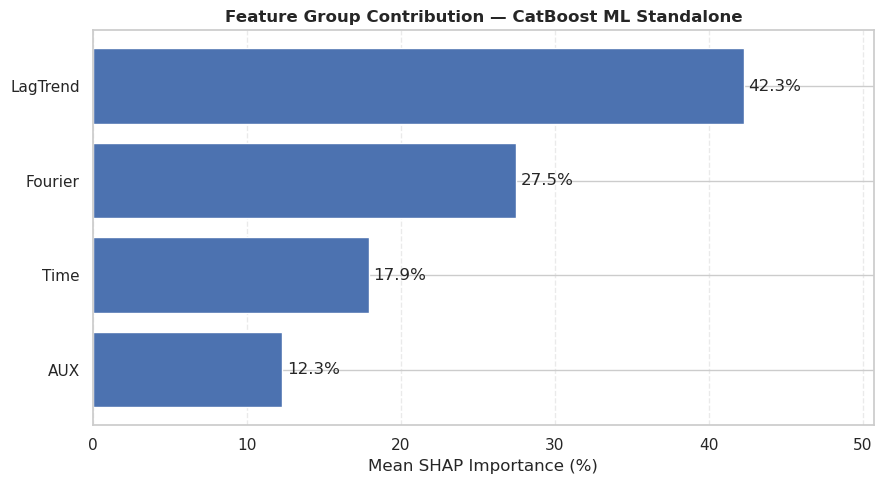

In [33]:
# =========================================================
# SHAP FEATURE GROUP IMPORTANCE - ML STANDALONE (CATBOOST)
# =========================================================

import shap

CAT_PARAMS = dict(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=0,
)

all_group_importance = []

for fold in folds:

    print(f"\n{'='*60}")
    print(f"Fold {fold['fold']}")

    train_df = fold["train"].copy()
    test_df  = fold["test"].copy()

    # ====================================
    # BUILD AUX TABLES
    # ====================================
    train_end = train_df["Date"].max()

    aux_tables = build_aux_features(
        inventory_train  = df_inventory_cleaned[
            df_inventory_cleaned["snapshot_date"] <= train_end],
        returns_train    = df_returns_cleaned[
            df_returns_cleaned["return_date"]     <= train_end],
        web_train        = df_web_traffic_cleaned[
            df_web_traffic_cleaned["date"]        <= train_end],
        shipments_train  = df_shipments_cleaned[
            df_shipments_cleaned["ship_date"]     <= train_end],
    )

    # ====================================
    # APPLY AUX FEATURES
    # ====================================
    train_df = apply_aux_features(train_df, aux_tables)
    test_df  = apply_aux_features(test_df,  aux_tables)

    # ====================================
    # CLEAN FEATURES
    # ====================================
    for df_ in [train_df, test_df]:
        df_[FEATURES] = df_[FEATURES].replace([np.inf, -np.inf], np.nan)

    fill_values = train_df[FEATURES].median()
    train_df[FEATURES] = train_df[FEATURES].fillna(fill_values)
    test_df[FEATURES]  = test_df[FEATURES].fillna(fill_values)

    # ====================================
    # TRAIN CATBOOST
    # ====================================
    X_train = train_df[FEATURES]
    y_train = train_df["LogRevenue"]

    cat_model = CatBoostRegressor(**CAT_PARAMS)
    cat_model.fit(X_train, y_train, verbose=False)

    # ====================================
    # SHAP
    # ====================================
    explainer  = shap.TreeExplainer(cat_model)
    shap_values = explainer.shap_values(X_train)

    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    shap_df = pd.DataFrame({
        "feature":    FEATURES,
        "importance": mean_abs_shap,
    })

    # ====================================
    # FEATURE GROUP MAP — đúng với FEATURES hiện tại
    # ====================================
    feature_group_map = {
        # TIME (8)
        "Month": "Time", "Day": "Time", "DayOfWeek": "Time",
        "DayOfYear": "Time", "Quarter": "Time",
        "WeekOfYear": "Time", "IsWeekend": "Time", "IsOddYear": "Time",

        # FOURIER (8)
        "doy_sin": "Fourier", "doy_cos": "Fourier",
        "dom_sin": "Fourier", "dom_cos": "Fourier",
        "dow_sin": "Fourier", "dow_cos": "Fourier",
        "month_sin": "Fourier", "month_cos": "Fourier",

        # LAG/TREND (5) — lag_7, lag_14 (không có lag_1)
        "lag_7": "LagTrend", "lag_14": "LagTrend",
        "ma_7": "LagTrend", "ma_30": "LagTrend", "std_30": "LagTrend",

        # AUX (8)
        "inv_stockout": "AUX", "inv_fillrate": "AUX",
        "inv_sellthru": "AUX", "returns_md": "AUX",
        "sessions_md": "AUX", "visitors_md": "AUX",
        "avg_ship_fee": "AUX", "avg_delivery_days": "AUX",
    }

    shap_df["group"] = (
        shap_df["feature"]
        .map(feature_group_map)
        .fillna("Other")
    )

    group_imp = (
        shap_df
        .groupby("group", as_index=False)["importance"]
        .sum()
    )

    group_imp["pct"]  = group_imp["importance"] / group_imp["importance"].sum() * 100
    group_imp["fold"] = fold["fold"]

    all_group_importance.append(group_imp)
    print(group_imp)

# =========================================================
# SUMMARY
# =========================================================
group_importance_df = pd.concat(all_group_importance, ignore_index=True)

summary = (
    group_importance_df
    .groupby("group")["pct"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
)

display(summary)

# =========================================================
# PLOT
# =========================================================
group_summary = (
    summary
    .reset_index()
    .rename(columns={"mean": "pct"})
    .sort_values("pct", ascending=True)
)

plt.figure(figsize=(9, 5))
bars = plt.barh(group_summary["group"], group_summary["pct"])

plt.xlabel("Mean SHAP Importance (%)")
plt.title("Feature Group Contribution — CatBoost ML Standalone")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
    )

plt.xlim(0, group_summary["pct"].max() * 1.2)
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_group_ml_standalone.png", dpi=150)
plt.show()

 Nhận xét SHAP - CatBoost (nhóm đặc trưng)
- **LagTrend (42.27)**: Quan trọng nhất, chi phối mạnh nhất trong mô hình.
- **Fourier (27.49)**: Đóng góp lớn thứ hai, phản ánh rõ yếu tố chu kỳ/mùa vụ.
- **Time (17.93)**: Ảnh hưởng, bởi xu hướng tổng thể.
- **AUX (12.31)**: Thấp nhất, vai trò bổ trợ.

### Kết luận
Mô hình CatBoost chủ yếu được giải thích bởi **LagTrend + Fourier (~70%)**, trong khi Time và AUX chỉ đóng vai trò phụ trợ.


  ABLATION — FOLD 1
  Train: 2012-07-04 → 2020-12-31
  Test : 2021-01-01 → 2021-06-30
  LightGBM   | Time                   | RMSE=   2,735,467 | MAE=   2,359,282 | R²=-1.0800 | AdjR²=-1.1768
  XGBoost    | Time                   | RMSE=   3,237,759 | MAE=   2,771,885 | R²=-1.9141 | AdjR²=-2.0496
  CatBoost   | Time                   | RMSE=   2,412,729 | MAE=   2,095,509 | R²=-0.6182 | AdjR²=-0.6934
  LightGBM   | Fourier                | RMSE=   2,712,694 | MAE=   2,357,593 | R²=-1.0456 | AdjR²=-1.1407
  XGBoost    | Fourier                | RMSE=   2,911,822 | MAE=   2,500,824 | R²=-1.3569 | AdjR²=-1.4665
  CatBoost   | Fourier                | RMSE=   2,373,967 | MAE=   2,080,242 | R²=-0.5666 | AdjR²=-0.6395
  LightGBM   | LagTrend               | RMSE=   1,249,119 | MAE=     881,860 | R²= 0.5663 | AdjR²= 0.5539
  XGBoost    | LagTrend               | RMSE=   1,269,994 | MAE=     865,668 | R²= 0.5517 | AdjR²= 0.5388
  CatBoost   | LagTrend               | RMSE=   1,267,552 | MAE= 

,Fold,Model,FeatureSet,RMSE,MAE,R2,Adj_R2
0,1,LightGBM,Time,2735467.10,2359281.69,-1.0800,-1.1768
1,1,XGBoost,Time,3237759.36,2771884.86,-1.9141,-2.0496
2,1,CatBoost,Time,2412728.61,2095509.22,-0.6182,-0.6934
3,1,LightGBM,Fourier,2712694.11,2357593.24,-1.0456,-1.1407
4,1,XGBoost,Fourier,2911821.72,2500823.96,-1.3569,-1.4665
...,...,...,...,...,...,...,...
175,4,XGBoost,Fourier+Lag+AUX,731593.69,517892.46,0.6519,0.6068
176,4,CatBoost,Fourier+Lag+AUX,665996.97,472188.98,0.7116,0.6742
177,4,LightGBM,All,667203.87,493724.93,0.7105,0.6560
178,4,XGBoost,All,656921.37,484601.75,0.7194,0.6665



  ABLATION — AVERAGE BY MODEL × FEATURE SET (sorted by RMSE)


,Model,FeatureSet,RMSE,MAE,R2,Adj_R2
1,CatBoost,All,7.163319e+05,5.135819e+05,0.7476,0.6997
14,CatBoost,Time+Lag+AUX,7.167899e+05,5.137930e+05,0.7467,0.7137
12,CatBoost,Time+Fourier+Lag,7.287400e+05,5.117953e+05,0.7413,0.7076
5,CatBoost,Fourier+Lag+AUX,7.299778e+05,5.154200e+05,0.7358,0.7013
4,CatBoost,Fourier+Lag,7.334309e+05,5.152686e+05,0.7355,0.7151
13,CatBoost,Time+Lag,7.751782e+05,5.436618e+05,0.7082,0.6857
6,CatBoost,Lag+AUX,8.281868e+05,6.016439e+05,0.6656,0.6398
7,CatBoost,LagTrend,1.118107e+06,7.734641e+05,0.3980,0.3810
0,CatBoost,AUX,1.792941e+06,1.536296e+06,-0.6776,-0.7548
3,CatBoost,Fourier+AUX,1.926997e+06,1.639919e+06,-0.8899,-1.0722


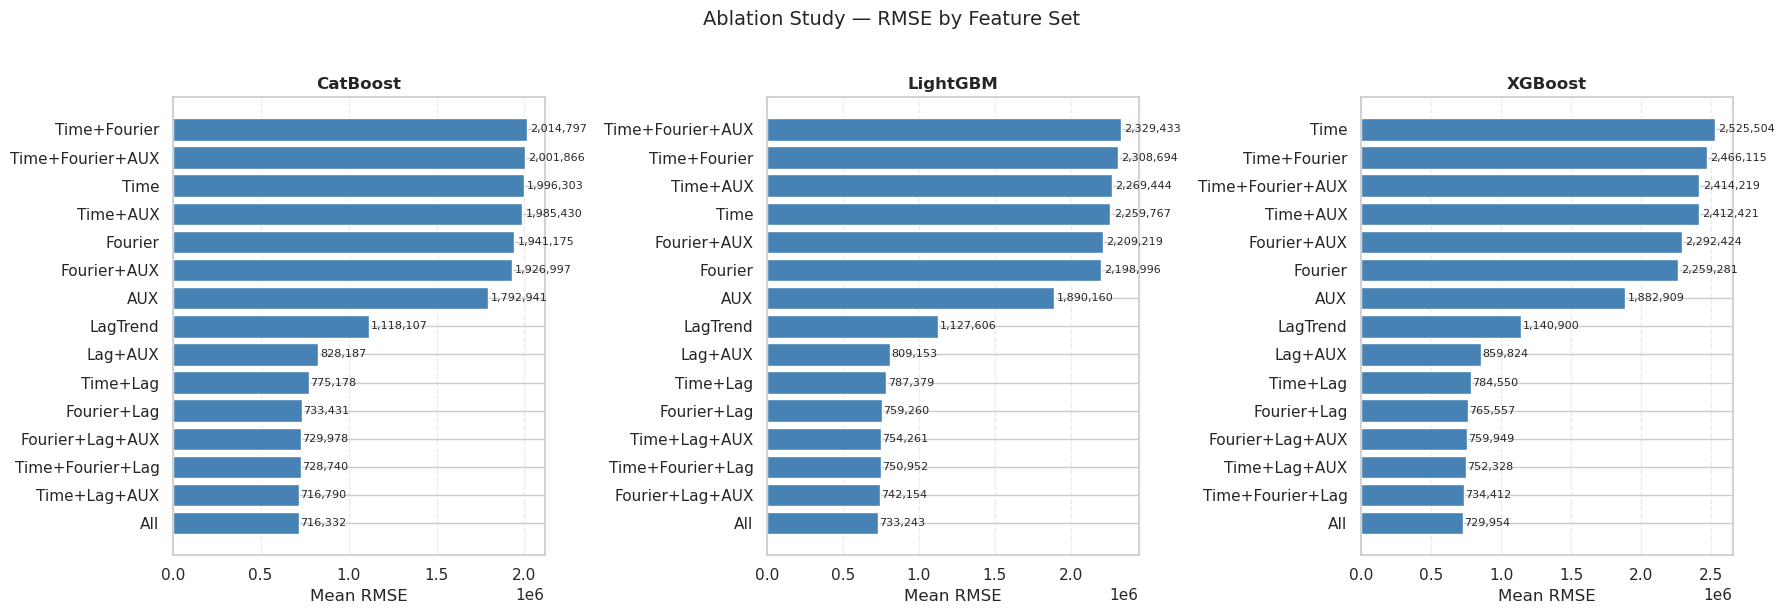

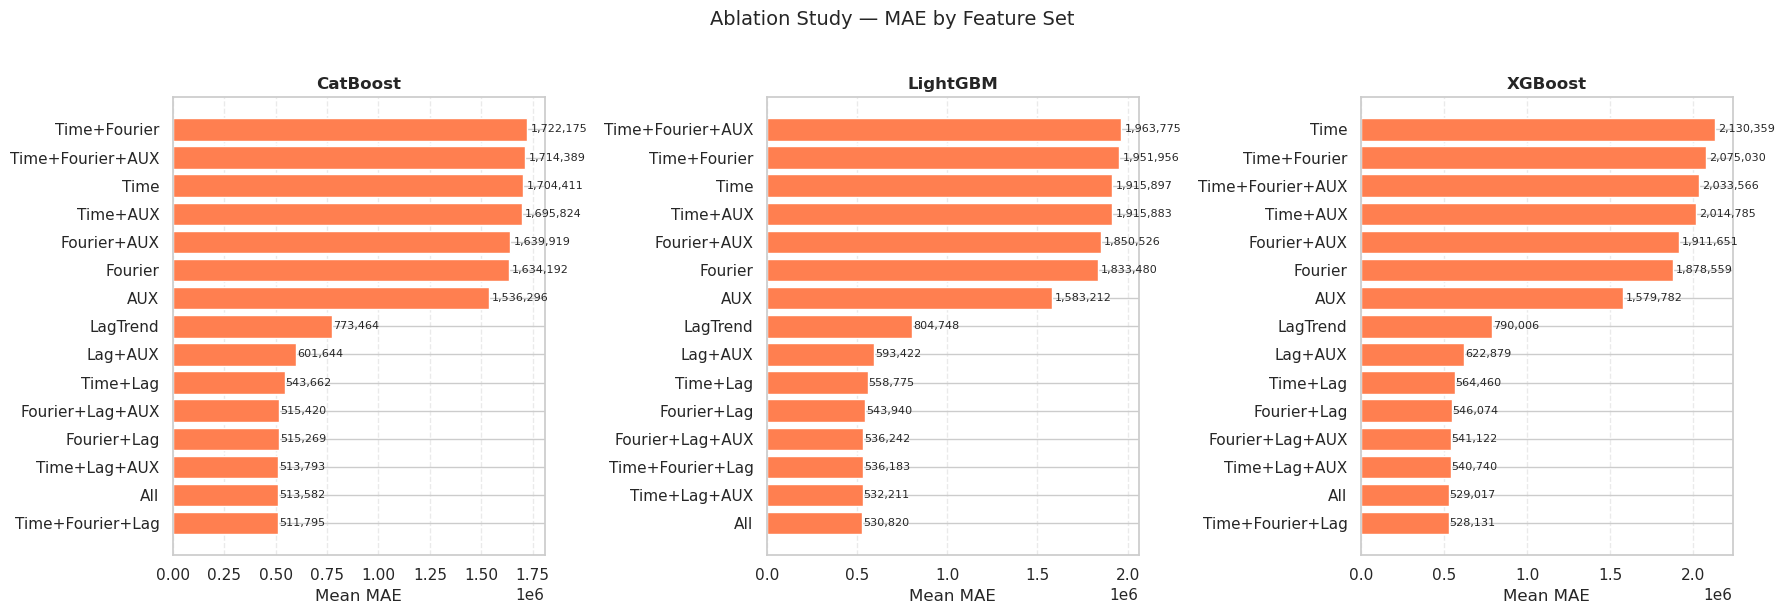

In [34]:
# =========================================================
# ABLATION STUDY - COMPLETE (4 FOLDS)
# =========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# =========================================================
# FEATURE GROUPS
# =========================================================

TIME_FEATURES = [
    'Month', 'Day', 'DayOfWeek', 'DayOfYear',
    'Quarter', 'WeekOfYear', 'IsWeekend', 'IsOddYear',
]

FOURIER_FEATURES = [
    'doy_sin', 'doy_cos',
    'dom_sin', 'dom_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
]

LAG_FEATURES = [
    'lag_7', 'lag_14',
    'ma_7', 'ma_30', 'std_30',
]

AUX_FEATURES = [
    'inv_stockout', 'inv_fillrate', 'inv_sellthru',
    'returns_md',
    'sessions_md', 'visitors_md',
    'avg_ship_fee', 'avg_delivery_days',
]

# =========================================================
# FEATURE SETS (single → pair → triple → full)
# =========================================================

feature_sets = {
    # Single
    "Time":                TIME_FEATURES,
    "Fourier":             FOURIER_FEATURES,
    "LagTrend":            LAG_FEATURES,
    "AUX":                 AUX_FEATURES,

    # Pair
    "Time+Fourier":        TIME_FEATURES + FOURIER_FEATURES,
    "Time+Lag":            TIME_FEATURES + LAG_FEATURES,
    "Time+AUX":            TIME_FEATURES + AUX_FEATURES,
    "Fourier+Lag":         FOURIER_FEATURES + LAG_FEATURES,
    "Fourier+AUX":         FOURIER_FEATURES + AUX_FEATURES,
    "Lag+AUX":             LAG_FEATURES + AUX_FEATURES,

    # Triple
    "Time+Fourier+Lag":    TIME_FEATURES + FOURIER_FEATURES + LAG_FEATURES,
    "Time+Fourier+AUX":    TIME_FEATURES + FOURIER_FEATURES + AUX_FEATURES,
    "Time+Lag+AUX":        TIME_FEATURES + LAG_FEATURES + AUX_FEATURES,
    "Fourier+Lag+AUX":     FOURIER_FEATURES + LAG_FEATURES + AUX_FEATURES,

    # Full
    "All":                 TIME_FEATURES + FOURIER_FEATURES + LAG_FEATURES + AUX_FEATURES,
}

# =========================================================
# HELPERS
# =========================================================

def adjusted_r2(r2, n, p):
    if n <= p + 1:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


def get_models():
    return {
        'LightGBM': LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
            n_jobs=-1,
            verbose=-1,
        ),
        'XGBoost': XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            random_state=42,
            n_jobs=-1,
            verbosity=0,
        ),
        'CatBoost': CatBoostRegressor(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            random_state=42,
            verbose=0,
        ),
    }

# =========================================================
# MAIN LOOP
# =========================================================

ablation_results = []

for fold in folds:

    fold_id  = fold["fold"]
    train_df = fold["train"].copy()
    test_df  = fold["test"].copy()

    print(f"\n{'='*65}")
    print(f"  ABLATION — FOLD {fold_id}")
    print(f"  Train: {train_df['Date'].min().date()} → {train_df['Date'].max().date()}")
    print(f"  Test : {test_df['Date'].min().date()} → {test_df['Date'].max().date()}")
    print(f"{'='*65}")

    # --------------------------------------------------
    # 1. BUILD AUX TABLES
    # --------------------------------------------------
    train_end = train_df["Date"].max()

    aux_tables = build_aux_features(
        inventory_train  = df_inventory_cleaned[
            df_inventory_cleaned["snapshot_date"] <= train_end],
        returns_train    = df_returns_cleaned[
            df_returns_cleaned["return_date"]     <= train_end],
        web_train        = df_web_traffic_cleaned[
            df_web_traffic_cleaned["date"]        <= train_end],
        shipments_train  = df_shipments_cleaned[
            df_shipments_cleaned["ship_date"]     <= train_end],
    )

    # --------------------------------------------------
    # 2. APPLY AUX FEATURES
    # --------------------------------------------------
    train_df = apply_aux_features(train_df, aux_tables)
    test_df  = apply_aux_features(test_df,  aux_tables)

    y_train_log = train_df["LogRevenue"]
    y_test_real = test_df["Revenue"]

    # --------------------------------------------------
    # 3. LOOP FEATURE SETS × MODELS
    # --------------------------------------------------
    for feature_name, feature_cols in feature_sets.items():

        # Clean NaN/Inf per feature set
        X_tr = train_df[feature_cols].copy().replace([np.inf, -np.inf], np.nan)
        X_te = test_df[feature_cols].copy().replace([np.inf, -np.inf], np.nan)

        fill_values = X_tr.median()
        X_tr = X_tr.fillna(fill_values)
        X_te = X_te.fillna(fill_values)

        # Fresh models mỗi feature set
        models = get_models()

        for model_name, model in models.items():

            # Fit
            model.fit(X_tr, y_train_log)

            # Predict log space
            pred_log    = model.predict(X_te)
            train_pred  = model.predict(X_tr)

            # Duan Smearing
            smear    = np.mean(np.exp(y_train_log.values - train_pred))

            # Back-transform
            pred_rev = np.expm1(pred_log) * smear
            pred_rev = np.maximum(pred_rev, 0)

            # Metrics
            rmse   = np.sqrt(mean_squared_error(y_test_real, pred_rev))
            mae    = mean_absolute_error(y_test_real, pred_rev)
            r2     = r2_score(y_test_real, pred_rev)
            adj_r2 = adjusted_r2(r2, len(y_test_real), len(feature_cols))

            print(
                f"  {model_name:<10}"
                f" | {feature_name:<22}"
                f" | RMSE={rmse:>12,.0f}"
                f" | MAE={mae:>12,.0f}"
                f" | R²={r2:>7.4f}"
                f" | AdjR²={adj_r2:>7.4f}"
            )

            ablation_results.append({
                "Fold":       fold_id,
                "Model":      model_name,
                "FeatureSet": feature_name,
                "RMSE":       round(rmse, 2),
                "MAE":        round(mae, 2),
                "R2":         round(r2, 4),
                "Adj_R2":     round(adj_r2, 4),
            })

# =========================================================
# SUMMARY
# =========================================================

ablation_df = pd.DataFrame(ablation_results)

print("\n" + "="*65)
print("  ABLATION — RAW RESULTS")
print("="*65)
display(ablation_df)

ablation_summary = (
    ablation_df
    .groupby(["Model", "FeatureSet"])[["RMSE", "MAE", "R2", "Adj_R2"]]
    .mean()
    .round(4)
    .reset_index()
    .sort_values(["Model", "RMSE"])
)

print("\n" + "="*65)
print("  ABLATION — AVERAGE BY MODEL × FEATURE SET (sorted by RMSE)")
print("="*65)
display(ablation_summary)

# =========================================================
# HELPER: vẽ 1 metric thành figure ngang 3 panel
# =========================================================

def _plot_metric(ablation_summary, metric, title, xlabel, color, filename):
    models_list = ablation_summary["Model"].unique()
    fig, axes   = plt.subplots(1, len(models_list), figsize=(18, 6), sharey=False)

    for ax, model_name in zip(axes, models_list):
        sub = (
            ablation_summary[ablation_summary["Model"] == model_name]
            .sort_values(metric, ascending=True)
        )

        bars = ax.barh(sub["FeatureSet"], sub[metric], color=color)

        for bar in bars:
            w = bar.get_width()
            ax.text(
                w * 1.01, bar.get_y() + bar.get_height() / 2,
                f"{w:,.0f}", va="center", fontsize=8,
            )

        ax.set_title(model_name, fontsize=12)
        ax.set_xlabel(xlabel)
        ax.grid(axis="x", linestyle="--", alpha=0.4)

    plt.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()


# =========================================================
# PLOT 1: RMSE by FeatureSet per Model
# =========================================================

_plot_metric(
    ablation_summary,
    metric   = "RMSE",
    title    = "Ablation Study — RMSE by Feature Set",
    xlabel   = "Mean RMSE",
    color    = "steelblue",
    filename = "ablation_rmse_by_featureset.png",
)

# =========================================================
# PLOT 2: MAE by FeatureSet per Model
# =========================================================

_plot_metric(
    ablation_summary,
    metric   = "MAE",
    title    = "Ablation Study — MAE by Feature Set",
    xlabel   = "Mean MAE",
    color    = "coral",
    filename = "ablation_mae_by_featureset.png",
)

 Nhận xét Ablation Study (RMSE)

- **LagTrend** là đặc trưng quan trọng nhất, giúp giảm RMSE rõ rệt ở cả 3 mô hình.
- Các tổ hợp có **LagTrend + Fourier/Time** thường cho kết quả tốt hơn so với chỉ dùng Time hoặc Fourier riêng lẻ.
- **AUX** đóng góp thấp, hầu như không cải thiện đáng kể khi thêm vào.
- Mô hình tốt nhất thường nằm ở nhóm **“Đầy đủ 4 nhóm đặc trưng**, cho RMSE thấp nhất.

--> Hiệu quả mô hình phụ thuộc chủ yếu vào **LagTrend**, trong khi các feature còn lại mang tính bổ trợ.

Nhìn qua cả 3 model, kết quả rất nhất quán: Lag features là nhân tố quyết định — bất kỳ feature set nào có Lag đều cho MAE thấp hơn hẳn (~500K-800K), trong khi các nhóm Time, Fourier, AUX đứng một mình đều cho MAE cao gấp 3–4 lần (~1.5M–2.1M). Thêm AUX hay Fourier vào Lag cải thiện thêm nhưng rất ít, và "All" luôn nằm trong top 3 thấp nhất nên dùng full feature set là lựa chọn an toàn.

### 5. Đề xuất chiến lược

C:\Users\lenovo\AppData\Local\Temp\ipykernel_18016\3415883137.py:478: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.98])


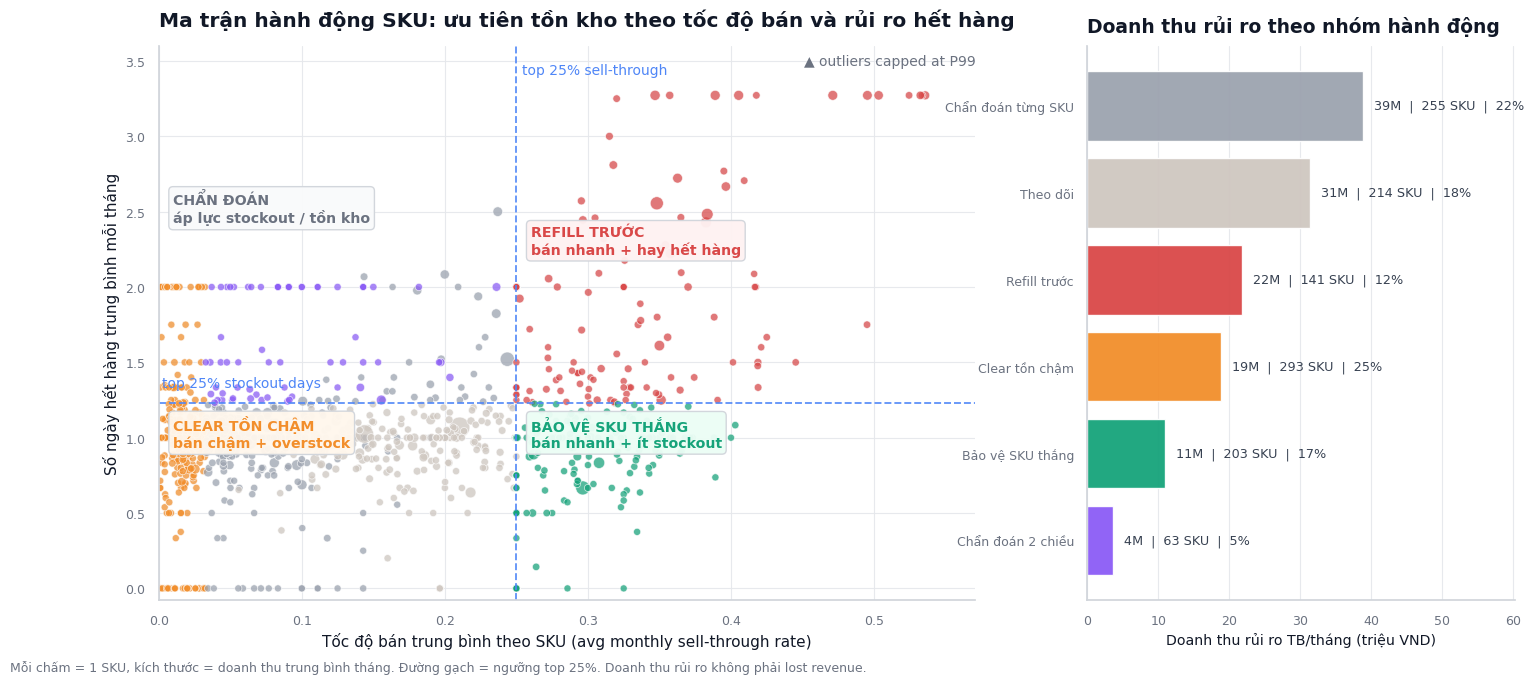

Plot A5 displayed


In [32]:
# -*- coding: utf-8 -*-
"""Shared helpers for Datathon 2026 EDA figures."""
from __future__ import annotations

from pathlib import Path
from typing import Optional, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# =========================================================
# COLOR PALETTE
# =========================================================

COL = {
    "navy":       "#1F3A5F",
    "blue":       "#2F6B9A",
    "teal":       "#2A9D8F",
    "green":      "#2A9D8F",
    "orange":     "#E76F51",
    "red":        "#C0392B",
    "gray":       "#6B7280",
    "light_gray": "#E5E7EB",
    "panel":      "#F9FAFB",
    "dark":       "#111827",
    "bg":         "#FFFFFF",
    "guide":      "#4F86F7",
    "grid":       "#E5E7EB",
}

plt.rcParams["font.family"]      = "DejaVu Sans"
plt.rcParams["axes.titleweight"] = "bold"

# =========================================================
# GENERAL HELPERS
# =========================================================

def ensure_dir(path: str | Path) -> Path:
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def find_file(
    data_dir: str | Path,
    filename: str,
    extra_dirs: Optional[Iterable[str | Path]] = None,
) -> Optional[Path]:
    data_dir   = Path(data_dir)
    candidates = [
        data_dir / filename,
        data_dir / "raw"       / filename,
        data_dir / "interim"   / filename,
        data_dir / "processed" / filename,
        data_dir / "marts"     / filename,
        Path.cwd() / filename,
        Path.cwd() / "data"            / filename,
        Path.cwd() / "data" / "raw"       / filename,
        Path.cwd() / "data" / "interim"   / filename,
        Path.cwd() / "data" / "processed" / filename,
        Path.cwd() / "data" / "marts"     / filename,
    ]
    if extra_dirs:
        for d in extra_dirs:
            d = Path(d)
            candidates.extend([
                d / filename,
                d / "raw"       / filename,
                d / "interim"   / filename,
                d / "processed" / filename,
            ])
    for p in candidates:
        if p.exists():
            return p
    return None


def read_csv_smart(
    data_dir: str | Path,
    filename: str,
    parse_dates=None,
    low_memory: bool = False,
) -> pd.DataFrame:
    path = find_file(data_dir, filename)
    if path is None:
        raise FileNotFoundError(
            f"Không tìm thấy {filename}. Hãy kiểm tra --data-dir."
        )
    return pd.read_csv(path, parse_dates=parse_dates, low_memory=low_memory)


def first_valid(s: pd.Series):
    s = s.dropna()
    return s.iloc[0] if len(s) else np.nan

# =========================================================
# AXIS / CHART HELPERS
# =========================================================

def style_axis(ax, xy: bool = False):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#D1D5DB")
    ax.spines["bottom"].set_color("#D1D5DB")
    ax.tick_params(axis="both", colors=COL["gray"], labelsize=9)
    ax.grid(
        True if xy else False,
        axis="both" if xy else "y",
        color=COL["grid"],
        lw=0.8,
        alpha=0.9,
    )
    ax.set_axisbelow(True)


def add_kpi_box(ax, title, value, subtitle, y, color, height=0.17):
    box = FancyBboxPatch(
        (0.03, y), 0.94, height,
        boxstyle="round,pad=0.018,rounding_size=0.025",
        linewidth=0.8,
        edgecolor="#E5E7EB",
        facecolor="#F9FAFB",
    )
    ax.add_patch(box)
    ax.text(0.07, y + height * 0.72, title,    fontsize=9.2,  color=COL["gray"])
    ax.text(0.07, y + height * 0.42, value,    fontsize=15.2, color=color, weight="bold")
    ax.text(0.07, y + height * 0.18, subtitle, fontsize=8.2,  color=COL["gray"])


def money_million_vi(x, pos=None):
    return f"{x/1e6:.0f}M"


def pct_fmt_fraction(x, pos=None):
    return f"{x*100:.0f}%"


def pct_fmt_percent(x, pos=None):
    return f"{x:.0f}%"


def add_period_shading_year_axis(ax):
    ax.axvline(2018.5, color=COL["gray"], lw=1.2, ls="--", alpha=0.8)
    ax.axvspan(2013,   2018.5, color="#D8E8F5", alpha=0.25, lw=0)
    ax.axvspan(2018.5, 2022,   color="#E5E7EB", alpha=0.25, lw=0)

# =========================================================
# SKU ACTION MATRIX HELPERS
# =========================================================

def build_sku_action_matrix(product_mart: pd.DataFrame) -> pd.DataFrame:
    df      = product_mart.copy()
    rev_med   = df["revenue"].median()          if "revenue"          in df.columns else 0
    stock_med = df["avg_stockout_days"].median() if "avg_stockout_days" in df.columns else 0

    def label(row):
        high_rev      = row.get("revenue", 0)          >= rev_med
        high_stockout = row.get("avg_stockout_days", 0) >= stock_med
        if high_rev and high_stockout:
            return "Priority Replenish"
        if high_rev and not high_stockout:
            return "Protect Winners"
        if not high_rev and high_stockout:
            return "Selective Reorder"
        return "Reduce/Markdown"

    df["sku_action"] = df.apply(label, axis=1)
    return df


def action_summary(action_matrix: pd.DataFrame) -> pd.DataFrame:
    agg = {"sku_count": ("product_id", "nunique"), "revenue": ("revenue", "sum")}
    if "avg_stockout_days" in action_matrix.columns:
        agg["avg_stockout_days"] = ("avg_stockout_days", "mean")
    else:
        agg["avg_stockout_days"] = ("revenue", "mean")

    return (
        action_matrix
        .groupby("sku_action", as_index=False)
        .agg(**agg)
        .sort_values("revenue", ascending=False)
    )

# =========================================================
# DATA LOADERS (dùng cho plot_a5)
# =========================================================

def load_item_level(df_orders, df_order_items, df_products):
    orders      = df_orders.copy()
    order_items = df_order_items.copy()
    products    = df_products.copy()

    keep_order_cols   = [c for c in ["order_id", "customer_id", "order_date", "order_status"] if c in orders.columns]
    keep_product_cols = [c for c in ["product_id", "product_name", "category", "segment", "price", "cogs"] if c in products.columns]

    orders   = orders[keep_order_cols].copy()
    products = products[keep_product_cols].copy()

    if (
        pd.api.types.is_string_dtype(orders["order_id"])
        and orders["order_id"].str.startswith("O").any()
    ):
        orders["order_id"] = orders["order_id"].str.replace("O", "", regex=False).astype(int)

    if not pd.api.types.is_integer_dtype(order_items["order_id"]):
        order_items["order_id"] = order_items["order_id"].astype(int)

    items = (
        order_items
        .merge(orders,   on="order_id",   how="left")
        .merge(products, on="product_id", how="left")
    )
    items["order_date"] = pd.to_datetime(items["order_date"])

    if "discount_amount" not in items.columns:
        items["discount_amount"] = 0
    items["discount_amount"] = items["discount_amount"].fillna(0)

    if "gross_merch_value" not in items.columns:
        items["gross_merch_value"] = items["quantity"] * items["unit_price"]
    if "net_item_revenue" not in items.columns:
        items["net_item_revenue"] = items["gross_merch_value"] - items["discount_amount"]
    if "item_cogs" not in items.columns:
        if "cogs" not in items.columns:
            raise ValueError("products.csv thiếu cột cogs để tính giá vốn.")
        items["item_cogs"] = items["quantity"] * items["cogs"]
    if "gross_profit" not in items.columns:
        items["gross_profit"] = items["net_item_revenue"] - items["item_cogs"]
    if "promo_used_flag" not in items.columns:
        promo_cols = [c for c in ["promo_id", "promo_id_p1", "promo_id_2", "promo_id_p2"] if c in items.columns]
        if promo_cols:
            items["promo_used_flag"] = items[promo_cols].notna().any(axis=1).astype(int)
        else:
            items["promo_used_flag"] = (items["discount_amount"] > 0).astype(int)

    return items


def load_inventory(df_inventory):
    inv = df_inventory.copy()
    inv["snapshot_date"] = pd.to_datetime(inv["snapshot_date"])
    return inv

# =========================================================
# PLOT A5 — SKU ACTION MATRIX
# =========================================================

def plot_a5(df_inventory, df_orders, df_order_items, df_products) -> dict:

    inv   = load_inventory(df_inventory)
    items = load_item_level(df_orders, df_order_items, df_products)

    inv["ym"]   = inv["snapshot_date"].dt.to_period("M").dt.to_timestamp()
    inv["year"] = inv["snapshot_date"].dt.year
    inv_post    = inv[inv["year"].between(2019, 2022)].copy()

    valid_status = ["delivered", "returned", "shipped"]
    items_post   = items[
        items["order_status"].isin(valid_status)
        & items["order_date"].dt.year.between(2019, 2022)
    ].copy()
    items_post["ym"] = items_post["order_date"].dt.to_period("M").dt.to_timestamp()

    revenue_pm = items_post.groupby(["product_id", "ym"], as_index=False).agg(
        revenue     = ("net_item_revenue", "sum"),
        units_sold  = ("quantity",         "sum"),
        orders      = ("order_id",         "nunique"),
    )

    agg_dict = {
        "sell_through_rate": "mean",
        "stockout_days":     "mean",
        "stockout_flag":     "mean",
        "overstock_flag":    "mean",
        "fill_rate":         "mean",
    }
    for optional_col in ["product_name", "category", "segment"]:
        if optional_col in inv_post.columns:
            agg_dict[optional_col] = first_valid

    inv_pm = (
        inv_post
        .groupby(["product_id", "ym"], as_index=False)
        .agg(agg_dict)
        .merge(revenue_pm, on=["product_id", "ym"], how="left")
    )

    for c in ["revenue", "units_sold", "orders"]:
        inv_pm[c] = inv_pm[c].fillna(0)
    for c in ["sell_through_rate", "stockout_days", "stockout_flag", "overstock_flag", "fill_rate"]:
        inv_pm[c] = pd.to_numeric(inv_pm[c], errors="coerce").clip(lower=0)

    inv_pm["stockout_flag"]  = inv_pm["stockout_flag"].clip(upper=1)
    inv_pm["overstock_flag"] = inv_pm["overstock_flag"].clip(upper=1)
    inv_pm["fill_rate"]      = inv_pm["fill_rate"].clip(upper=1)

    sku = inv_pm.groupby("product_id", as_index=False).agg(
        sell_through_avg  = ("sell_through_rate", "mean"),
        stockout_days_avg = ("stockout_days",     "mean"),
        stockout_rate     = ("stockout_flag",     "mean"),
        overstock_rate    = ("overstock_flag",    "mean"),
        fill_rate_avg     = ("fill_rate",         "mean"),
        revenue_total     = ("revenue",           "sum"),
        active_months     = ("ym",                "nunique"),
    )
    sku["avg_monthly_revenue"] = (
        sku["revenue_total"] / sku["active_months"].replace(0, np.nan)
    ).fillna(0)
    sku = sku[sku["sell_through_avg"].notna() & sku["stockout_days_avg"].notna()].copy()

    st_q25,    st_q75    = sku["sell_through_avg"].quantile([0.25, 0.75])
    stock_q25, stock_q75 = sku["stockout_days_avg"].quantile([0.25, 0.75])
    over_q75             = sku["overstock_rate"].quantile(0.75)

    def classify_sku(r):
        high_sell      = r["sell_through_avg"]  >= st_q75
        low_sell       = r["sell_through_avg"]  <= st_q25
        high_stockout  = r["stockout_days_avg"] >= stock_q75
        low_stockout   = r["stockout_days_avg"] <= stock_q25
        high_overstock = r["overstock_rate"]    >= over_q75
        if high_sell and high_stockout:
            return "Refill trước"
        if high_sell and (not high_stockout):
            return "Bảo vệ SKU thắng"
        if low_sell and high_overstock:
            return "Clear tồn chậm"
        if high_stockout and high_overstock:
            return "Chẩn đoán 2 chiều"
        if (not high_sell) and (not low_sell) and (not high_stockout) and (not high_overstock):
            return "Theo dõi"
        return "Chẩn đoán từng SKU"

    sku["action_bucket"] = sku.apply(classify_sku, axis=1)

    bucket_order = [
        "Clear tồn chậm", "Chẩn đoán từng SKU", "Chẩn đoán 2 chiều",
        "Refill trước", "Theo dõi", "Bảo vệ SKU thắng",
    ]
    colors = {
        "Clear tồn chậm":     "#F28E2B",
        "Chẩn đoán từng SKU": "#9CA3AF",
        "Chẩn đoán 2 chiều":  "#8B5CF6",
        "Refill trước":       "#D94848",
        "Theo dõi":           "#CFC7C0",
        "Bảo vệ SKU thắng":   "#16A37A",
        "dark":               "#111827",
        "gray":               "#6B7280",
        "grid":               "#E5E7EB",
        "guide":              "#4F86F7",
    }

    bucket_summary = sku.groupby("action_bucket", as_index=False).agg(
        sku_count           = ("product_id",          "count"),
        revenue_total       = ("revenue_total",        "sum"),
        avg_monthly_revenue = ("avg_monthly_revenue",  "sum"),
    )
    bucket_summary["sku_share"]               = bucket_summary["sku_count"] / bucket_summary["sku_count"].sum()
    bucket_summary["avg_monthly_revenue_mn"]  = bucket_summary["avg_monthly_revenue"] / 1e6
    bucket_summary["action_bucket"]           = pd.Categorical(
        bucket_summary["action_bucket"], categories=bucket_order, ordered=True
    )
    bucket_summary = bucket_summary.sort_values("avg_monthly_revenue_mn", ascending=False).reset_index(drop=True)

    stockout_cap              = sku["stockout_days_avg"].quantile(0.99)
    sku["stockout_days_plot"] = sku["stockout_days_avg"].clip(upper=stockout_cap)

    rev = sku["avg_monthly_revenue"].fillna(0)
    sku["bubble_size"] = (
        26 + 190 * (rev - rev.min()) / (rev.max() - rev.min())
        if rev.max() > rev.min() else 75
    )

    def add_box(ax, x, y, text, color, fc):
        ax.text(
            x, y, text, ha="left", va="center",
            fontsize=10.2, color=color, weight="bold",
            bbox=dict(boxstyle="round,pad=0.30", fc=fc, ec="#D1D5DB", lw=1.0, alpha=0.96),
        )

    # ── FIGURE ────────────────────────────────────────────────────────────────
    fig    = plt.figure(figsize=(17.5, 7.2), facecolor="white")
    gs     = GridSpec(1, 2, width_ratios=[2.10, 1.10], figure=fig, wspace=0.18)
    ax_sc  = fig.add_subplot(gs[0, 0])
    ax_bar = fig.add_subplot(gs[0, 1])

    # ── SCATTER ───────────────────────────────────────────────────────────────
    ax_sc.scatter(
        sku["sell_through_avg"], sku["stockout_days_plot"],
        s=sku["bubble_size"], color="#D1D5DB", alpha=0.20,
        edgecolors="none", zorder=1,
    )
    for bucket in bucket_order:
        d = sku[sku["action_bucket"] == bucket]
        if len(d):
            ax_sc.scatter(
                d["sell_through_avg"], d["stockout_days_plot"],
                s=d["bubble_size"], color=colors[bucket], alpha=0.72,
                edgecolors="white", linewidth=0.55, zorder=2,
            )

    ax_sc.axvline(st_q75,    color=colors["guide"], ls="--", lw=1.35, alpha=0.88)
    ax_sc.axhline(stock_q75, color=colors["guide"], ls="--", lw=1.35, alpha=0.88)

    x_min = max(0, sku["sell_through_avg"].min() - 0.015)
    x_max = sku["sell_through_avg"].max() + 0.035
    y_max = max(stockout_cap * 1.10, stock_q75 * 1.35)
    ax_sc.set_xlim(x_min, x_max)
    ax_sc.set_ylim(-0.08, y_max)

    ax_sc.text(st_q75 + 0.004, y_max * 0.955, "top 25% sell-through",
               color=colors["guide"], fontsize=10, ha="left", va="center")
    ax_sc.text(x_min + 0.002, stock_q75 + y_max * 0.025, "top 25% stockout days",
               color=colors["guide"], fontsize=10, ha="left", va="bottom")

    add_box(ax_sc, x_min + 0.010, stock_q75 + y_max * 0.36,
            "CHẨN ĐOÁN\náp lực stockout / tồn kho", "#6B7280", "#F9FAFB")
    add_box(ax_sc, x_min + 0.010, max(0.55, stock_q25 + 0.15),
            "CLEAR TỒN CHẬM\nbán chậm + overstock", colors["Clear tồn chậm"], "#FFF7ED")
    add_box(ax_sc, st_q75 + 0.010, stock_q75 + y_max * 0.30,
            "REFILL TRƯỚC\nbán nhanh + hay hết hàng", colors["Refill trước"], "#FEF2F2")
    add_box(ax_sc, st_q75 + 0.010, max(0.55, stock_q25 + 0.15),
            "BẢO VỆ SKU THẮNG\nbán nhanh + ít stockout", colors["Bảo vệ SKU thắng"], "#ECFDF5")

    ax_sc.text(x_max, y_max * 0.985, "▲ outliers capped at P99",
               ha="right", va="top", fontsize=10, color=colors["gray"])

    ax_sc.set_title(
        "Ma trận hành động SKU: ưu tiên tồn kho theo tốc độ bán và rủi ro hết hàng",
        loc="left", fontsize=14.5, color=colors["dark"], pad=14,
    )
    ax_sc.set_xlabel(
        "Tốc độ bán trung bình theo SKU (avg monthly sell-through rate)",
        fontsize=11, color=colors["dark"],
    )
    ax_sc.set_ylabel("Số ngày hết hàng trung bình mỗi tháng", fontsize=11, color=colors["dark"])
    style_axis(ax_sc, xy=True)

    # ── BAR CHART ─────────────────────────────────────────────────────────────
    bar_data   = bucket_summary.copy()
    bar_colors = [colors[str(b)] for b in bar_data["action_bucket"]]
    y          = np.arange(len(bar_data))

    ax_bar.barh(y, bar_data["avg_monthly_revenue_mn"], color=bar_colors, alpha=0.95)
    ax_bar.invert_yaxis()
    ax_bar.set_yticks(y)
    ax_bar.set_yticklabels(bar_data["action_bucket"], fontsize=10.2, color=colors["dark"])
    ax_bar.set_xlabel("Doanh thu rủi ro TB/tháng (triệu VND)", fontsize=10.2, color=colors["dark"])
    ax_bar.set_title(
        "Doanh thu rủi ro theo nhóm hành động",
        loc="left", fontsize=13.5, color=colors["dark"], pad=10,
    )
    style_axis(ax_bar, xy=True)
    ax_bar.grid(True,  axis="x", color=colors["grid"])
    ax_bar.grid(False, axis="y")

    max_val = bar_data["avg_monthly_revenue_mn"].max()
    ax_bar.set_xlim(0, max_val * 1.55 if max_val > 0 else 1)

    for i, r in bar_data.iterrows():
        val   = r["avg_monthly_revenue_mn"]
        label = f"{val:.0f}M  |  {int(r['sku_count'])} SKU  |  {r['sku_share']*100:.0f}%"
        ax_bar.text(val + max_val * 0.04, i, label,
                    va="center", ha="left", fontsize=9.2, color="#374151")

    # ── FOOTNOTE ──────────────────────────────────────────────────────────────
    fig.text(
        0.04, 0.012,
        "Mỗi chấm = 1 SKU, kích thước = doanh thu trung bình tháng. "
        "Đường gạch = ngưỡng top 25%. Doanh thu rủi ro không phải lost revenue.",
        fontsize=9.0, color=colors["gray"],
    )

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()
    plt.close(fig)

    return {
        "a5_refill_sku_count":              int((sku["action_bucket"] == "Refill trước").sum()),
        "a5_clear_sku_count":               int((sku["action_bucket"] == "Clear tồn chậm").sum()),
        "a5_top_bucket":                    str(bucket_summary.iloc[0]["action_bucket"]),
        "a5_top_bucket_monthly_revenue_mn": float(bucket_summary.iloc[0]["avg_monthly_revenue_mn"]),
    }

# =========================================================
# ENTRY POINT
# =========================================================

_ = plot_a5(
    df_inventory  = inventory,
    df_orders     = orders,
    df_order_items = order_items,
    df_products   = products,
)

print("Plot A5 displayed")

Refill trước (141 SKU)
- Doanh thu rủi ro: **22M VND/tháng**
- Bán nhanh + stockout cao  
→ Nhóm áp lực cao nhất, đang mất doanh thu thực do thiếu hàng  
→ Cần ưu tiên bổ sung tồn ngay

 Bảo vệ SKU thắng (203 SKU)
- Doanh thu rủi ro: **11M VND/tháng**
- Bán nhanh + ít stockout  
→ Nhóm vận hành tốt  
→ Duy trì và cảnh báo sớm khi có dấu hiệu thiếu hàng

 Clear tồn chậm (293 SKU)
- Doanh thu rủi ro: **19M VND/tháng**
- Bán chậm + tồn cao  
→ Vốn bị khóa, nguy cơ phải markdown  
→ Cần kế hoạch giải phóng hàng có kiểm soát

 Chẩn đoán SKU (255 SKU)
- Doanh thu rủi ro: **39M VND/tháng (cao nhất)**
- Bán chậm nhưng vẫn stockout  
→ Vấn đề nằm ở phân bổ / dự báo / lịch nhập sai  
→ Cần phân tích nguyên nhân trước khi tối ưu tồn kho

Nhận xét tổng thể
- Revenue-at-risk tập trung chủ yếu ở **Refill + Chẩn đoán (~61M VND/tháng)**  
- Tồn kho hiện chưa phân bổ theo mức độ đóng góp doanh thu

### 6. So sánh tổng thể các mô hình

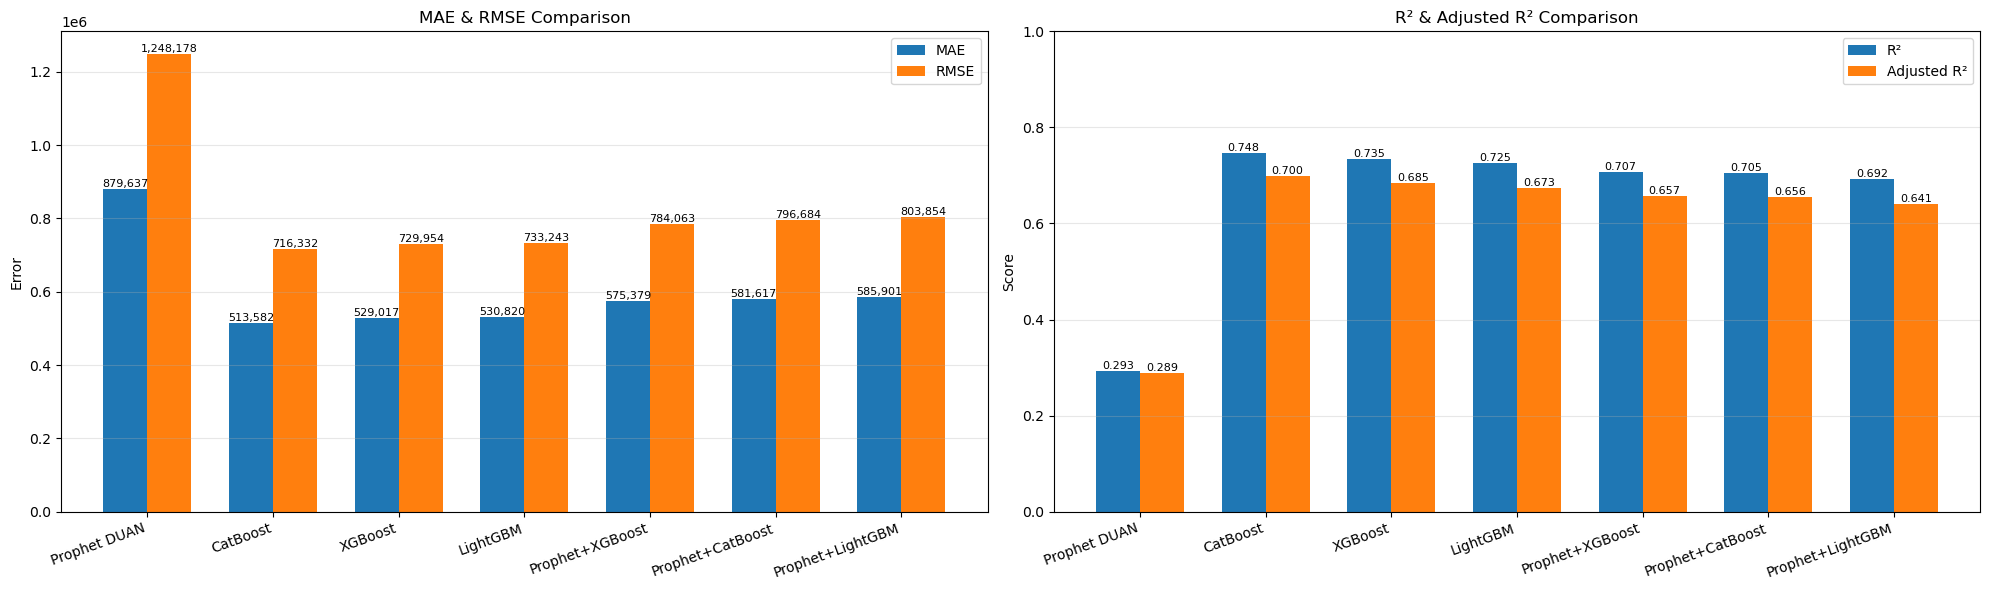

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ======================
# Data
# ======================
data = {
    "Model": [
        "Prophet DUAN",
        "CatBoost",
        "XGBoost",
        "LightGBM",
        "Prophet+XGBoost",
        "Prophet+CatBoost",
        "Prophet+LightGBM"
    ],
    "MAE": [
        879636.62,
        513581.9125,
        529017.2950,
        530820.2150,
        575379.1150,
        581617.1925,
        585900.9875
    ],
    "RMSE": [
        1248178.42,
        716331.8875,
        729953.8475,
        733243.2375,
        784062.5975,
        796684.1575,
        803853.8875
    ],
    "R2": [
        0.2933,
        0.7476,
        0.7352,
        0.7254,
        0.7065,
        0.7053,
        0.6921
    ],
    "Adj_R2": [
        0.2893,
        0.6997,
        0.6849,
        0.6734,
        0.6575,
        0.6561,
        0.6406
    ]
}

df = pd.DataFrame(data)

models = df["Model"]
x = np.arange(len(models))
width = 0.35

# ======================
# CREATE FOLDER
# ======================
save_path = "outputs/figures/model"
os.makedirs(save_path, exist_ok=True)

# ======================
# FIGURE 1x2
# ======================
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# ======================
# HÌNH 1: MAE + RMSE
# ======================
axes[0].bar(x - width/2, df["MAE"], width, label="MAE")
axes[0].bar(x + width/2, df["RMSE"], width, label="RMSE")

axes[0].set_title("MAE & RMSE Comparison")
axes[0].set_ylabel("Error")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=20, ha="right")
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

for i in range(len(models)):
    axes[0].text(x[i] - width/2, df["MAE"][i],
                 f"{df['MAE'][i]:,.0f}",
                 ha='center', va='bottom', fontsize=8)

    axes[0].text(x[i] + width/2, df["RMSE"][i],
                 f"{df['RMSE'][i]:,.0f}",
                 ha='center', va='bottom', fontsize=8)

# ======================
# HÌNH 2: R2 + Adj R2
# ======================
axes[1].bar(x - width/2, df["R2"], width, label="R²")
axes[1].bar(x + width/2, df["Adj_R2"], width, label="Adjusted R²")

axes[1].set_title("R² & Adjusted R² Comparison")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=20, ha="right")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

for i in range(len(models)):
    axes[1].text(x[i] - width/2, df["R2"][i],
                 f"{df['R2'][i]:.3f}",
                 ha='center', va='bottom', fontsize=8)

    axes[1].text(x[i] + width/2, df["Adj_R2"][i],
                 f"{df['Adj_R2'][i]:.3f}",
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()

# ======================
# SAVE FIGURE
# ======================
plt.savefig(f"{save_path}/model_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

CatBoost cho kết quả tốt nhất với MAE và RMSE thấp nhất, trong khi các mô hình hybrid (Prophet + ML) không cải thiện mà còn làm suy giảm hiệu năng so với mô hình ML thuần.  

Về R², CatBoost và XGBoost dẫn đầu (~0.74–0.75), cho thấy mô hình cây quyết định phù hợp nhất với dữ liệu doanh thu này.